In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [63]:
df = pd.read_parquet("data/training_data.parquet")

It seems like promotions are pop ups generated on the Fingerhut website after the user performs some other actions, such as browsing for products or completing their web application. It would be good to look into what events "trigger" these promotions (if any). In other words, what are the action(s) leading up to the event 'promotion_created', either based on a fixed number of previous events or a window of time before the event.

It would also be good to look at when these promotions are created with respect to certain milestones.

Also would be good to look at what the users next actions are following the generation of this promotion (either based on time or a fixed number of events).

In [ ]:
df.loc[df['outcome'] == 'unsuccessful', 'event_names'].reset_index(drop=True).head()

In [92]:
df[df['outcome'] == 'unsuccessful'].head(1)

,id,events,event_names,timestamps,journey_length,outcome,start_timestamp,end_timestamp,current_datetime
0,-1005528678 -2059117939,"[12, 4, 4, 4, 1, 1, 21, 1]","[application_web_approved, browse_products, br...","[2021-06-10T10:16:43.000000, 2021-06-10T10:18:...",8,unsuccessful,2021-06-10 10:16:43+00:00,2022-06-11 12:16:15+00:00,2021-08-20 03:23:36+00:00


In [96]:
df[df['outcome'] == 'unsuccessful'].reset_index(drop=True).head()

,id,events,event_names,timestamps,journey_length,outcome,start_timestamp,end_timestamp,current_datetime
0,-1005528678 -2059117939,"[12, 4, 4, 4, 1, 1, 21, 1]","[application_web_approved, browse_products, br...","[2021-06-10T10:16:43.000000, 2021-06-10T10:18:...",8,unsuccessful,2021-06-10 10:16:43+00:00,2022-06-11 12:16:15+00:00,2021-08-20 03:23:36+00:00
1,550319820 1907517993,"[22, 2, 12, 1, 24, 24, 24, 24, 1, 21, 1, 1, 21...","[pre-application_(3rd_party_affiliates), campa...","[2021-11-24T06:00:00.000000, 2021-11-24T06:00:...",14,unsuccessful,2021-11-24 06:00:00+00:00,2022-09-12 12:07:39+00:00,2022-05-10 21:58:34+00:00
2,-931437166 -273076191,"[2, 19, 19, 19, 19, 19, 19, 19, 3, 12, 4, 4, 4...","[campaign_click, application_web_view, applica...","[2021-11-16T06:00:00.000000, 2021-11-16T18:27:...",58,unsuccessful,2021-11-16 06:00:00+00:00,2022-08-12 00:00:00+00:00,2022-08-06 21:35:26+00:00
3,-1633366293 2048161844,"[12, 4, 11, 5, 1]","[application_web_approved, browse_products, ad...","[2022-06-20T06:29:48.000000, 2022-06-20T06:32:...",5,unsuccessful,2022-06-20 06:29:48+00:00,2022-08-19 07:04:43+00:00,2022-08-06 21:35:26+00:00
4,14655434 -620023259,"[19, 19, 19, 19, 19, 19, 3, 19, 12, 4]","[application_web_view, application_web_view, a...","[2022-04-22T12:50:44.000000, 2022-04-22T12:50:...",10,unsuccessful,2022-04-22 12:50:44+00:00,2022-12-15 12:17:12+00:00,2022-08-06 21:35:26+00:00


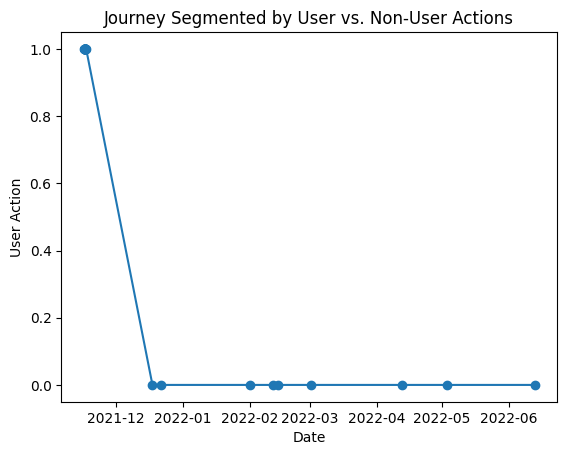

In [110]:
sample = df[df['outcome'] == 'unsuccessful'].reset_index(drop=True).loc[2]

plt.plot(
    sample['timestamps'],
    1 - np.isin(sample['events'], [1, 20, 21]).astype('int'),
    marker='o'
)
plt.xlabel('Date')
plt.ylabel('User Action')
plt.title('Journey Segmented by User vs. Non-User Actions')
plt.show()

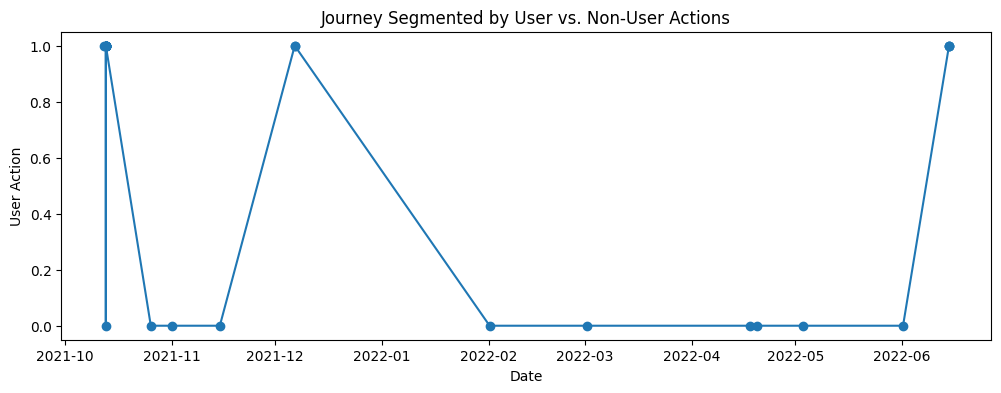

In [114]:
sample = df[df['outcome'] == 'unsuccessful'].reset_index(drop=True).loc[7]

plt.figure(figsize=(12, 4))
plt.plot(
    sample['timestamps'],
    1 - np.isin(sample['events'], [1, 20, 21]).astype('int'),
    marker='o'
)
plt.xlabel('Date')
plt.ylabel('User Action')
plt.title('Journey Segmented by User vs. Non-User Actions')
plt.show()

In [118]:
df[(df['start_timestamp'] < '2021-11-01') & (df['outcome'] == 'unsuccessful')].reset_index(drop=True).head()

,id,events,event_names,timestamps,journey_length,outcome,start_timestamp,end_timestamp,current_datetime
0,-1005528678 -2059117939,"[12, 4, 4, 4, 1, 1, 21, 1]","[application_web_approved, browse_products, br...","[2021-06-10T10:16:43.000000, 2021-06-10T10:18:...",8,unsuccessful,2021-06-10 10:16:43+00:00,2022-06-11 12:16:15+00:00,2021-08-20 03:23:36+00:00
1,-1863127150 408027667,[12],[application_web_approved],[2021-01-17T23:25:06.000000],1,unsuccessful,2021-01-17 23:25:06+00:00,2021-06-06 12:16:10+00:00,2021-01-20 03:40:59+00:00
2,57827615 -1100023417,"[19, 19, 3, 19, 19, 12, 19, 1, 21, 1]","[application_web_view, application_web_view, a...","[2021-04-16T01:22:48.000000, 2021-04-16T01:25:...",10,unsuccessful,2021-04-16 01:22:48+00:00,2022-05-12 19:58:32+00:00,2021-05-27 06:47:57+00:00
3,402729126 821483213,"[2, 19, 19, 19, 19, 19, 19, 19, 19, 3, 12, 1, ...","[campaign_click, application_web_view, applica...","[2021-10-12T06:00:00.000000, 2021-10-12T21:47:...",29,unsuccessful,2021-10-12 06:00:00+00:00,2022-10-01 03:43:46+00:00,2022-06-20 13:14:14+00:00
4,-1683635079 1237298863,"[2, 12, 24, 24, 24, 24, 1, 21, 1, 4, 4, 4, 4, ...","[campaign_click, application_web_approved, cam...","[2021-04-17T06:00:00.000000, 2021-04-17T23:53:...",20,unsuccessful,2021-04-17 06:00:00+00:00,2022-04-02 07:11:35+00:00,2021-08-21 14:54:41+00:00


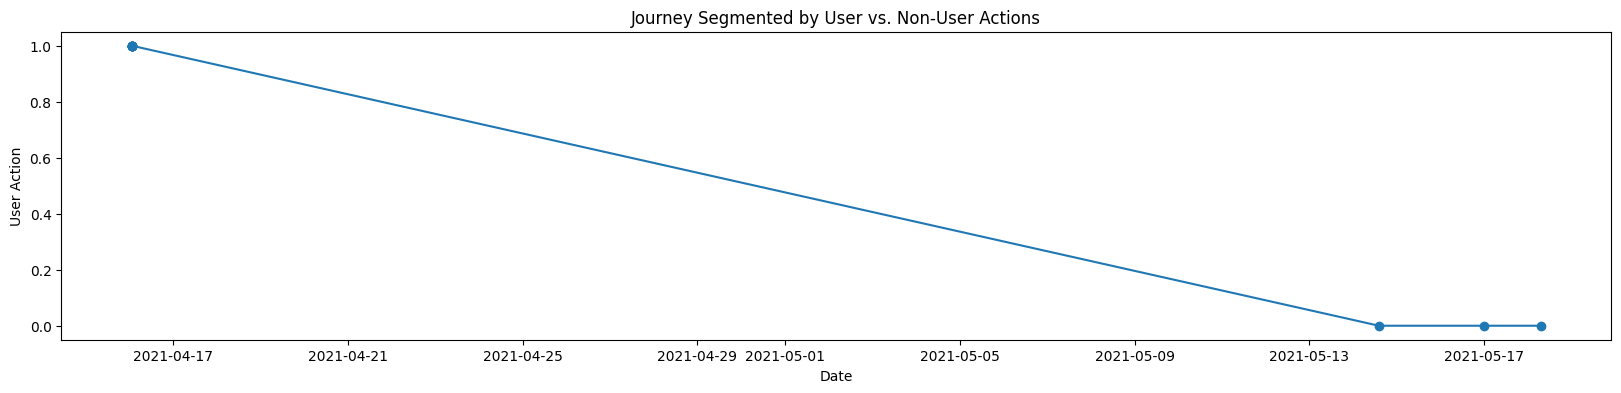

In [121]:
sample = df[(df['start_timestamp'] < '2021-11-01') & (df['outcome'] == 'unsuccessful')].reset_index(drop=True).loc[2]

plt.figure(figsize=(20, 4))
plt.plot(
    sample['timestamps'],
    1 - np.isin(sample['events'], [1, 20, 21]).astype('int'),
    marker='o'
)
plt.xlabel('Date')
plt.ylabel('User Action')
plt.title('Journey Segmented by User vs. Non-User Actions')
plt.show()

In [83]:
event_numbers = []
journey_times = []
journey_lengths = []
journey_time_proportions = []
previous_events = []
previous_time_diffs = []
next_events = []
next_time_diffs = []

for i, row in enumerate(df.itertuples(index=False)):
    promotion_indices = np.where(row.event_names == 'promotion_created')[0]

    if len(promotion_indices) > 0:
        event_numbers.extend(promotion_indices + 1)
        journey_times.extend((row.timestamps[promotion_indices] - row.timestamps[0]) / np.timedelta64(1, 'D'))
        journey_lengths.extend(len(promotion_indices) * [(row.timestamps[-1] - row.timestamps[0]) / np.timedelta64(1, 'D')])
        journey_time_proportions.extend((promotion_indices + 1) / len(row.event_names))
        previous_indices = promotion_indices - 1
        previous_events.extend(row.event_names[previous_indices])
        previous_time_diffs.extend((row.timestamps[promotion_indices] - row.timestamps[previous_indices]) / np.timedelta64(1, 'D'))

        next_indices = promotion_indices + 1
        if next_indices[-1] < len(row.event_names):
            next_events.extend(row.event_names[next_indices])
        else:
            next_events.extend(np.append(row.event_names[next_indices[:len(next_indices) - 1]], 'None'))

        if next_indices[-1] < len(row.event_names):
            next_time_diffs.extend((row.timestamps[next_indices] - row.timestamps[promotion_indices]) / np.timedelta64(1, 'D'))
        else:
            next_time_diffs.extend(np.append((row.timestamps[next_indices[:len(next_indices) - 1]] - row.timestamps[promotion_indices[:len(promotion_indices) - 1]]) / np.timedelta64(1, 'D'), np.nan))


events_df = pd.DataFrame({
    'event_number': event_numbers,
    'days_into_journey': journey_times,
    'days_in_journey': journey_lengths,
    'relative_event_progress_through_journey': journey_time_proportions,
    'previous_event': previous_events,
    'time_delta_previous': previous_time_diffs,
    'next_event': next_events,
    'time_delta_next': next_time_diffs
})

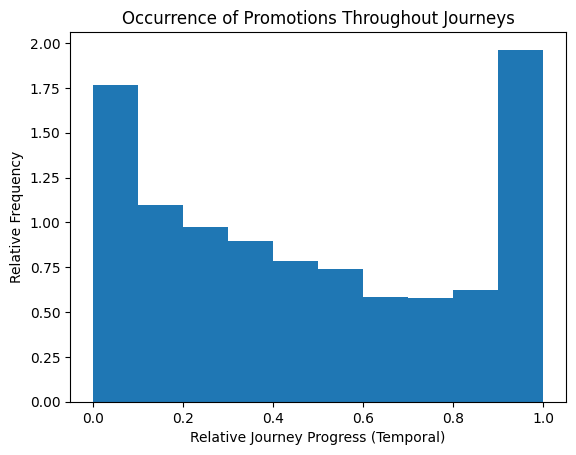

In [84]:
plt.hist(events_df['days_into_journey'] / events_df['days_in_journey'], density=True)
plt.xlabel('Relative Journey Progress (Temporal)')
plt.ylabel('Relative Frequency')
plt.title('Occurrence of Promotions Throughout Journeys')
plt.show()

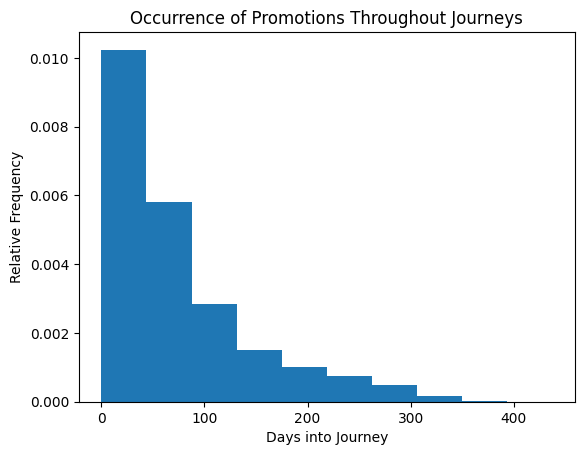

In [85]:
plt.hist(events_df['days_into_journey'], density=True)
plt.xlabel('Days into Journey')
plt.ylabel('Relative Frequency')
plt.title('Occurrence of Promotions Throughout Journeys')
plt.show()

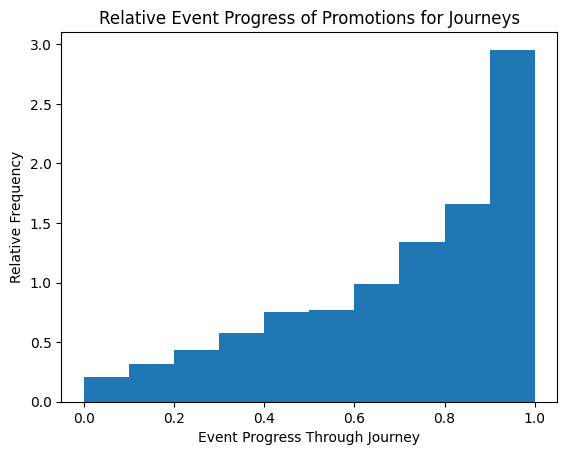

In [86]:
plt.hist(events_df['relative_event_progress_through_journey'], density=True)
plt.xlabel('Event Progress Through Journey')
plt.ylabel('Relative Frequency')
plt.title('Relative Event Progress of Promotions for Journeys')
plt.show()

In [87]:
events_df.groupby('previous_event')['time_delta_previous'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=12)

,count,mean,median,var
previous_event,,,,
promotion_created,5414563,19.225372,10.559711,1058.454753
catalog_(mail),3173469,24.685639,21.875648,970.368772
browse_products,2131621,8.346371,1.608854,432.584397
campaignemail_clicked,1042974,15.265339,10.797373,486.779556
begin_checkout,757938,4.689891,0.021574,253.054608
view_cart,729822,5.726098,0.022512,341.375354
application_web_approved,685226,14.266991,9.171053,448.581254
add_to_cart,325243,1.131166,0.000035,58.165445
application_web_view,208464,13.388392,9.847789,685.425235


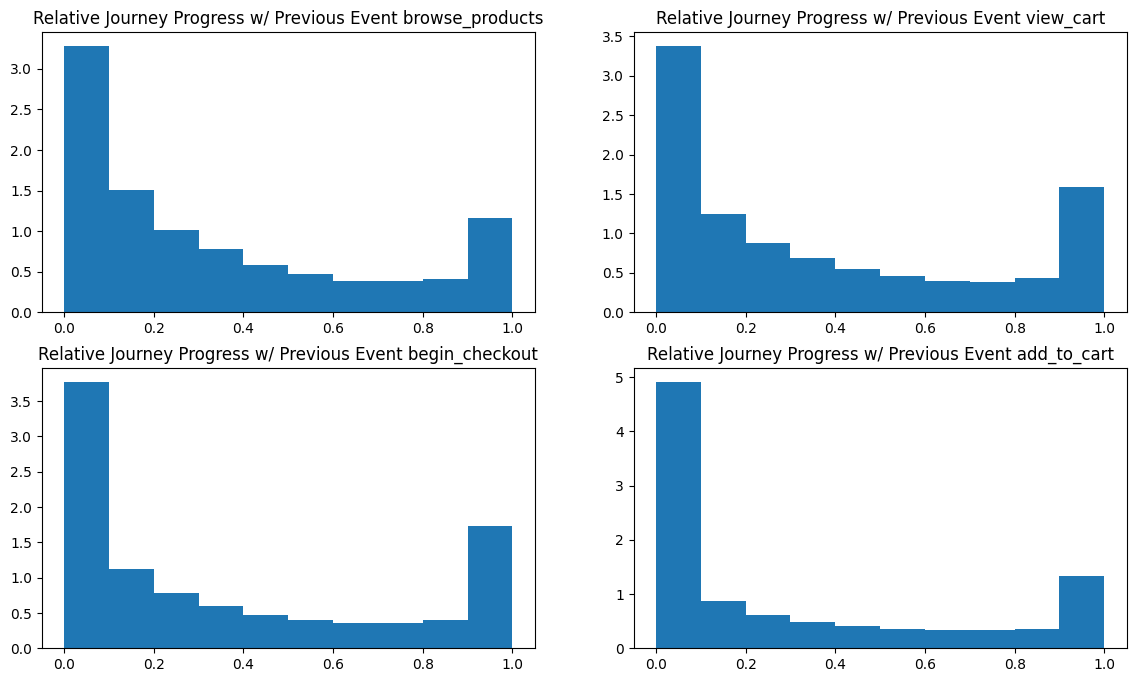

In [88]:
prev_events = ['browse_products', 'view_cart', 'begin_checkout', 'add_to_cart']

plt.figure(figsize=(14, 8))
for i, event in enumerate(prev_events):
    plt.subplot(2, 2, i+1)
    plt.hist(events_df.loc[events_df['previous_event'] == event, 'days_into_journey'] /
         events_df.loc[events_df['previous_event'] == event, 'days_in_journey'],
         density=True
    )
    plt.title(f'Relative Journey Progress w/ Previous Event {event}')

plt.show()

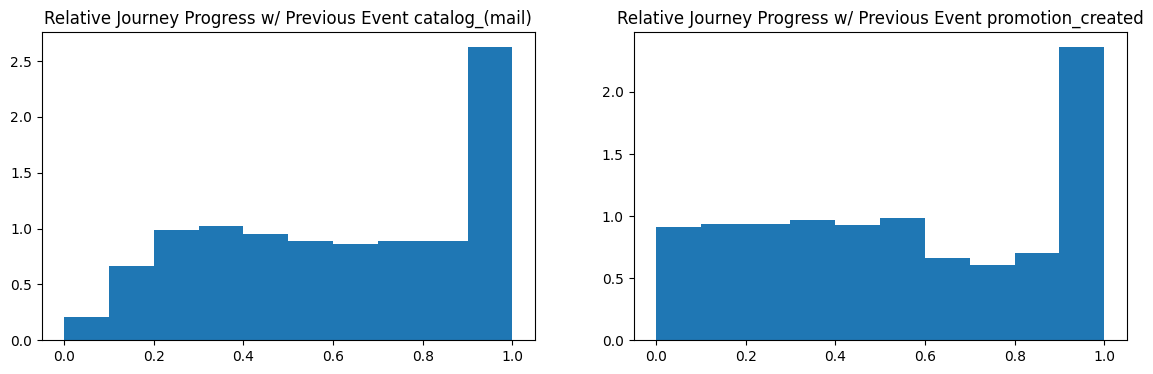

In [89]:
prev_events = ['catalog_(mail)', 'promotion_created']

plt.figure(figsize=(14, 4))
for i, event in enumerate(prev_events):
    plt.subplot(1, 2, i+1)
    plt.hist(events_df.loc[events_df['previous_event'] == event, 'days_into_journey'] /
         events_df.loc[events_df['previous_event'] == event, 'days_in_journey'],
         density=True
    )
    plt.title(f'Relative Journey Progress w/ Previous Event {event}')

plt.show()

Now let's separate the analysis for successful and unsuccessful journeys.

In [64]:
event_numbers = []
journey_times = []
journey_lengths = []
journey_time_proportions = []
previous_events = []
previous_time_diffs = []
next_events = []
next_time_diffs = []

for i, row in enumerate(df[df['outcome'] == 'successful'].itertuples(index=False)):
    promotion_indices = np.where(row.event_names == 'promotion_created')[0]

    if len(promotion_indices) > 0:
        event_numbers.extend(promotion_indices + 1)
        journey_times.extend((row.timestamps[promotion_indices] - row.timestamps[0]) / np.timedelta64(1, 'D'))
        journey_lengths.extend(len(promotion_indices) * [(row.timestamps[-1] - row.timestamps[0]) / np.timedelta64(1, 'D')])
        journey_time_proportions.extend((promotion_indices + 1) / len(row.event_names))
        previous_indices = promotion_indices - 1
        previous_events.extend(row.event_names[previous_indices])
        previous_time_diffs.extend((row.timestamps[promotion_indices] - row.timestamps[previous_indices]) / np.timedelta64(1, 'D'))

        next_indices = promotion_indices + 1
        if next_indices[-1] < len(row.event_names):
            next_events.extend(row.event_names[next_indices])
        else:
            next_events.extend(np.append(row.event_names[next_indices[:len(next_indices) - 1]], 'None'))

        if next_indices[-1] < len(row.event_names):
            next_time_diffs.extend((row.timestamps[next_indices] - row.timestamps[promotion_indices]) / np.timedelta64(1, 'D'))
        else:
            next_time_diffs.extend(np.append((row.timestamps[next_indices[:len(next_indices) - 1]] - row.timestamps[promotion_indices[:len(promotion_indices) - 1]]) / np.timedelta64(1, 'D'), np.nan))


events_df_successful = pd.DataFrame({
    'event_number': event_numbers,
    'days_into_journey': journey_times,
    'days_in_journey': journey_lengths,
    'relative_event_progress_through_journey': journey_time_proportions,
    'previous_event': previous_events,
    'time_delta_previous': previous_time_diffs,
    'next_event': next_events,
    'time_delta_next': next_time_diffs
})

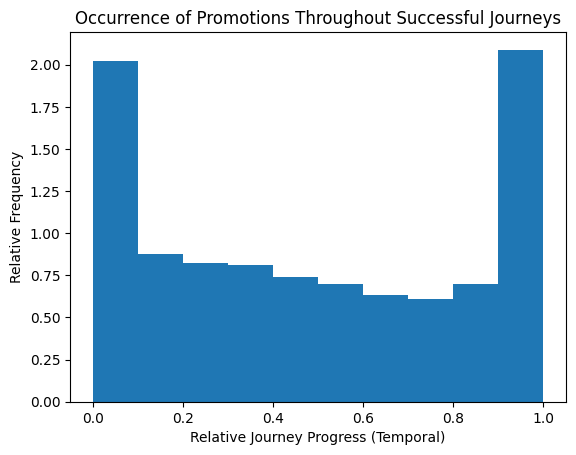

In [65]:
plt.hist(events_df_successful['days_into_journey'] / events_df_successful['days_in_journey'], density=True)
plt.xlabel('Relative Journey Progress (Temporal)')
plt.ylabel('Relative Frequency')
plt.title('Occurrence of Promotions Throughout Successful Journeys')
plt.show()

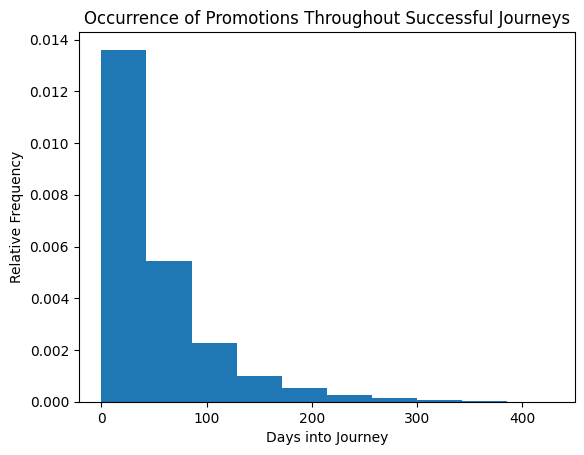

In [66]:
plt.hist(events_df_successful['days_into_journey'], density=True)
plt.xlabel('Days into Journey')
plt.ylabel('Relative Frequency')
plt.title('Occurrence of Promotions Throughout Successful Journeys')
plt.show()

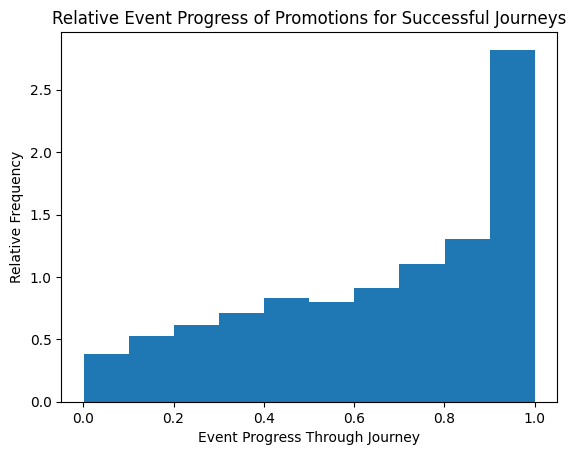

In [67]:
plt.hist(events_df_successful['relative_event_progress_through_journey'], density=True)
plt.xlabel('Event Progress Through Journey')
plt.ylabel('Relative Frequency')
plt.title('Relative Event Progress of Promotions for Successful Journeys')
plt.show()

In [68]:
events_df_successful.groupby('previous_event')['time_delta_previous'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=12)

,count,mean,median,var
previous_event,,,,
promotion_created,160407,11.888439,6.795891,492.610416
browse_products,149934,4.691628,0.025394,236.167626
catalog_(mail),84396,15.118270,14.965810,512.247011
begin_checkout,63006,2.316352,0.021447,166.813979
view_cart,61268,2.621177,0.021748,235.501774
campaignemail_clicked,45777,10.725468,8.047037,280.589627
add_to_cart,27983,0.547755,0.002384,37.938091
application_web_approved,25076,8.625265,0.004190,248.401983
application_web_view,10155,7.017383,0.021655,321.319825


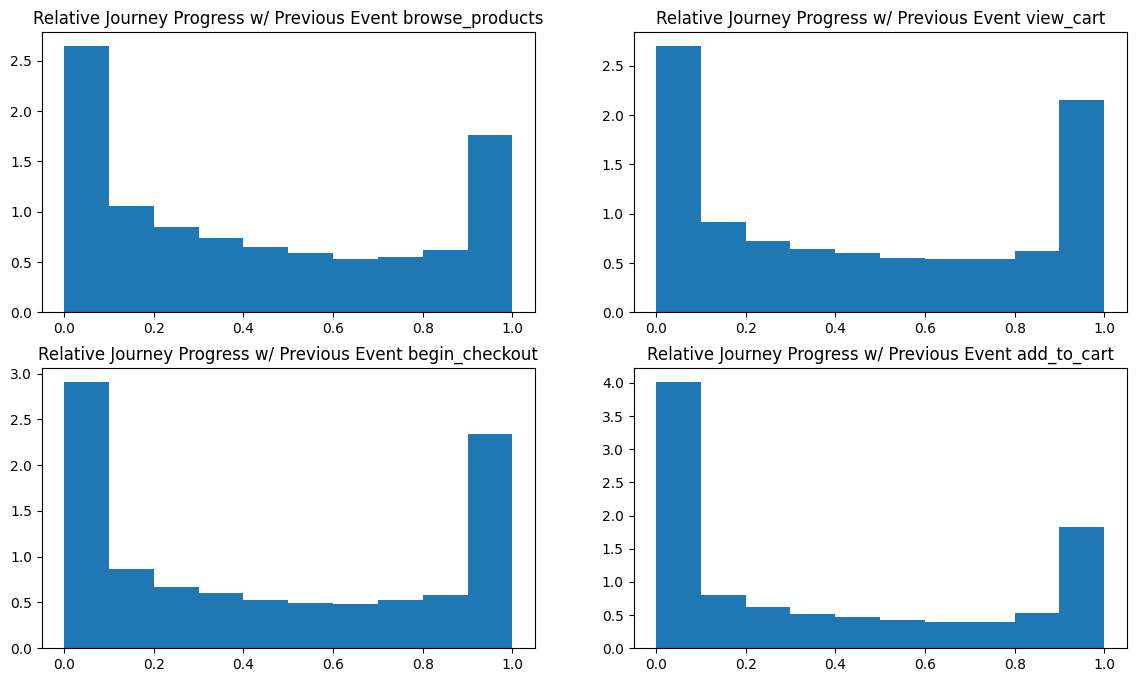

In [69]:
prev_events = ['browse_products', 'view_cart', 'begin_checkout', 'add_to_cart']

plt.figure(figsize=(14, 8))
for i, event in enumerate(prev_events):
    plt.subplot(2, 2, i+1)
    plt.hist(events_df_successful.loc[events_df_successful['previous_event'] == event, 'days_into_journey'] /
         events_df_successful.loc[events_df_successful['previous_event'] == event, 'days_in_journey'],
         density=True
    )
    plt.title(f'Relative Journey Progress w/ Previous Event {event}')

plt.show()

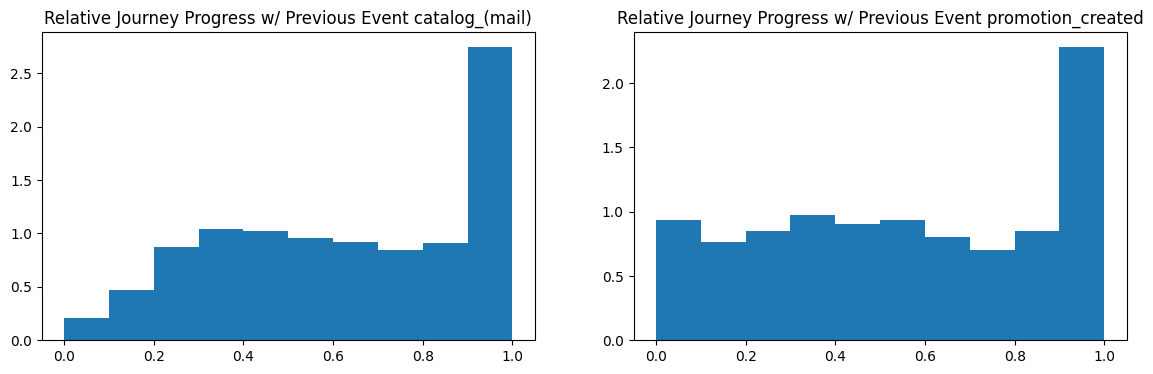

In [ ]:
prev_events = ['catalog_(mail)', 'promotion_created']

plt.figure(figsize=(14, 4))
for i, event in enumerate(prev_events):
    plt.subplot(1, 2, i+1)
    plt.hist(events_df_successful.loc[events_df_successful['previous_event'] == event, 'days_into_journey'] /
         events_df_successful.loc[events_df_successful['previous_event'] == event, 'days_in_journey'],
         density=True
    )
    plt.title(f'Relative Journey Progress w/ Previous Event {event}')

plt.show()

In [ ]:
successful_events_grouped = events_df_successful.groupby(['previous_event', 'next_event'])
display(successful_events_grouped['time_delta_previous'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=12))
display(successful_events_grouped['time_delta_next'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=10))

,,count,mean,median,var
previous_event,next_event,,,,
promotion_created,catalog_(mail),59549,10.233391,7.279942,162.826253
browse_products,browse_products,50333,2.192446,0.022581,126.827081
promotion_created,promotion_created,44149,14.391363,13.401481,421.650525
browse_products,promotion_created,31934,8.153199,2.481470,231.946174
catalog_(mail),promotion_created,30619,20.217432,21.299618,445.343392
promotion_created,None,20775,23.635409,18.381262,635.113956
browse_products,catalog_(mail),20484,12.549649,10.611134,168.899695
catalog_(mail),catalog_(mail),18946,18.192342,21.872685,383.591828
promotion_created,browse_products,18755,8.414070,0.591725,617.136432


,,count,mean,median,var
previous_event,next_event,,,,
promotion_created,catalog_(mail),59549,5.559544,3.108275,47.006068
browse_products,browse_products,50333,5.407163,0.956273,212.400953
promotion_created,promotion_created,44149,15.734973,3.587847,476.408119
browse_products,promotion_created,31934,10.133842,4.356308,168.505210
catalog_(mail),promotion_created,30619,16.737248,13.447141,301.966892
browse_products,catalog_(mail),20484,5.815355,3.977569,48.675880
catalog_(mail),catalog_(mail),18946,15.069507,6.122766,203.301021
promotion_created,browse_products,18755,13.548540,3.656574,689.285534
browse_products,view_cart,14919,5.306672,1.478079,115.556440


In [76]:
event_numbers = []
journey_times = []
journey_lengths = []
journey_time_proportions = []
previous_events = []
previous_time_diffs = []
next_events = []
next_time_diffs = []

for i, row in enumerate(df[df['outcome'] == 'unsuccessful'].itertuples(index=False)):
    promotion_indices = np.where(row.event_names == 'promotion_created')[0]

    if len(promotion_indices) > 0:
        event_numbers.extend(promotion_indices + 1)
        journey_times.extend((row.timestamps[promotion_indices] - row.timestamps[0]) / np.timedelta64(1, 'D'))
        journey_lengths.extend(len(promotion_indices) * [(row.timestamps[-1] - row.timestamps[0]) / np.timedelta64(1, 'D')])
        journey_time_proportions.extend((promotion_indices + 1) / len(row.event_names))
        previous_indices = promotion_indices - 1
        previous_events.extend(row.event_names[previous_indices])
        previous_time_diffs.extend((row.timestamps[promotion_indices] - row.timestamps[previous_indices]) / np.timedelta64(1, 'D'))

        next_indices = promotion_indices + 1
        if next_indices[-1] < len(row.event_names):
            next_events.extend(row.event_names[next_indices])
        else:
            next_events.extend(np.append(row.event_names[next_indices[:len(next_indices) - 1]], 'None'))

        if next_indices[-1] < len(row.event_names):
            next_time_diffs.extend((row.timestamps[next_indices] - row.timestamps[promotion_indices]) / np.timedelta64(1, 'D'))
        else:
            next_time_diffs.extend(np.append((row.timestamps[next_indices[:len(next_indices) - 1]] - row.timestamps[promotion_indices[:len(promotion_indices) - 1]]) / np.timedelta64(1, 'D'), np.nan))


events_df_unsuccessful = pd.DataFrame({
    'event_number': event_numbers,
    'days_into_journey': journey_times,
    'days_in_journey': journey_lengths,
    'relative_event_progress_through_journey': journey_time_proportions,
    'previous_event': previous_events,
    'time_delta_previous': previous_time_diffs,
    'next_event': next_events,
    'time_delta_next': next_time_diffs
})

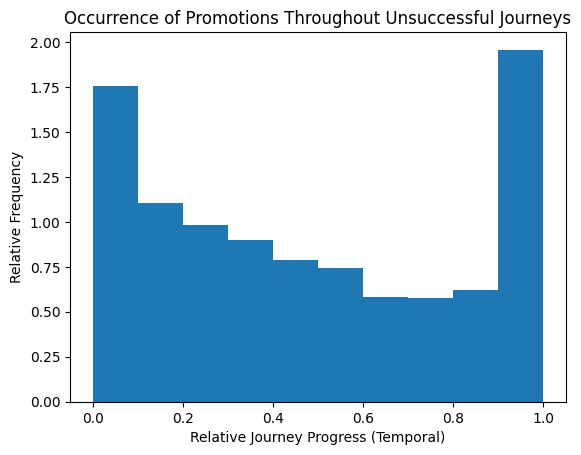

In [77]:
plt.hist(events_df_unsuccessful['days_into_journey'] / events_df_unsuccessful['days_in_journey'], density=True)
plt.xlabel('Relative Journey Progress (Temporal)')
plt.ylabel('Relative Frequency')
plt.title('Occurrence of Promotions Throughout Unsuccessful Journeys')
plt.show()

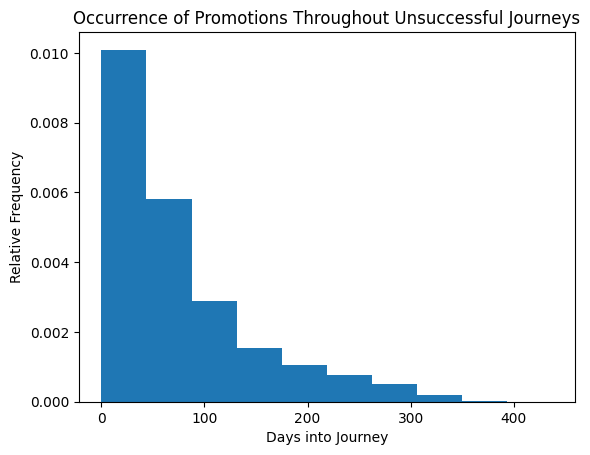

In [78]:
plt.hist(events_df_unsuccessful['days_into_journey'], density=True)
plt.xlabel('Days into Journey')
plt.ylabel('Relative Frequency')
plt.title('Occurrence of Promotions Throughout Unsuccessful Journeys')
plt.show()

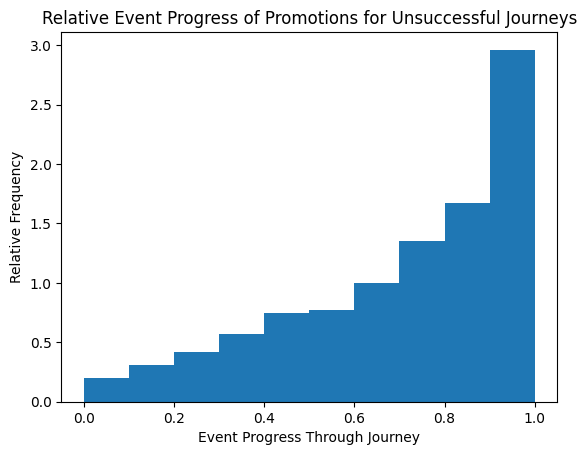

In [79]:
plt.hist(events_df_unsuccessful['relative_event_progress_through_journey'], density=True)
plt.xlabel('Event Progress Through Journey')
plt.ylabel('Relative Frequency')
plt.title('Relative Event Progress of Promotions for Unsuccessful Journeys')
plt.show()

In [80]:
events_df_unsuccessful.groupby('previous_event')['time_delta_previous'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=12)

,count,mean,median,var
previous_event,,,,
promotion_created,5254156,19.449365,10.560590,1074.036225
catalog_(mail),3089073,24.947028,21.877361,980.316079
browse_products,1981687,8.622888,1.934537,446.358313
campaignemail_clicked,997197,15.473745,10.954225,495.255564
begin_checkout,694932,4.905087,0.021597,260.316776
view_cart,668554,6.010641,0.022650,350.113797
application_web_approved,660150,14.481294,9.568067,454.930548
add_to_cart,297260,1.186087,0.000023,60.034653
application_web_view,198309,13.714638,10.450116,701.887080


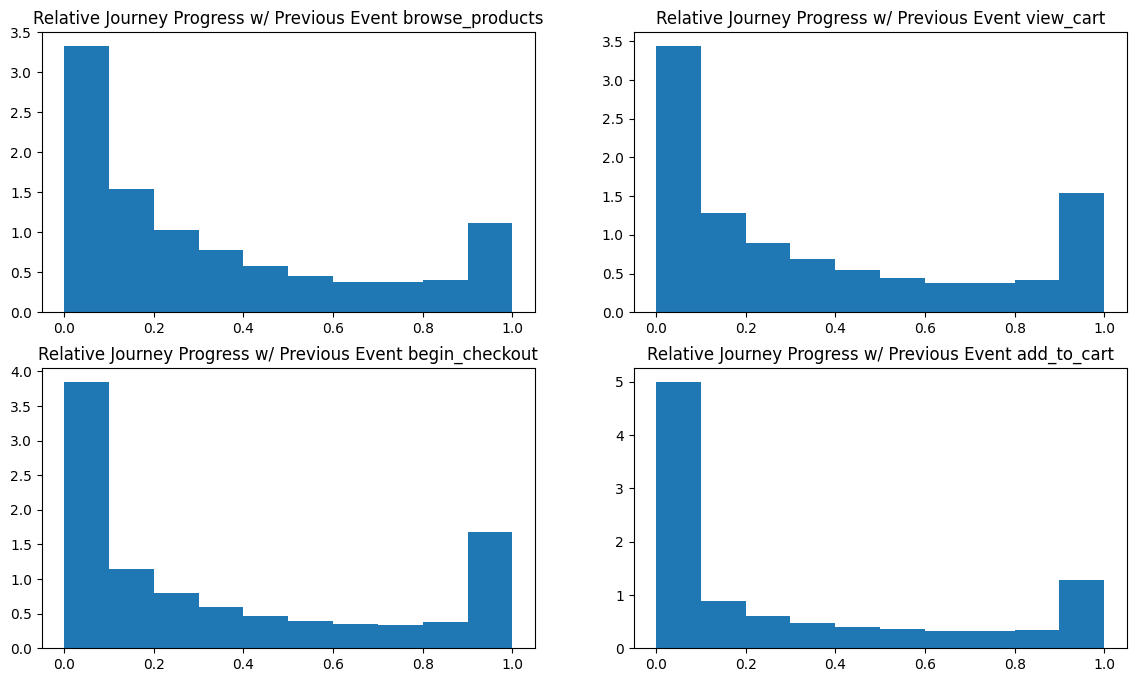

In [81]:
prev_events = ['browse_products', 'view_cart', 'begin_checkout', 'add_to_cart']

plt.figure(figsize=(14, 8))
for i, event in enumerate(prev_events):
    plt.subplot(2, 2, i+1)
    plt.hist(events_df_unsuccessful.loc[events_df_unsuccessful['previous_event'] == event, 'days_into_journey'] /
         events_df_unsuccessful.loc[events_df_unsuccessful['previous_event'] == event, 'days_in_journey'],
         density=True
    )
    plt.title(f'Relative Journey Progress w/ Previous Event {event}')

plt.show()

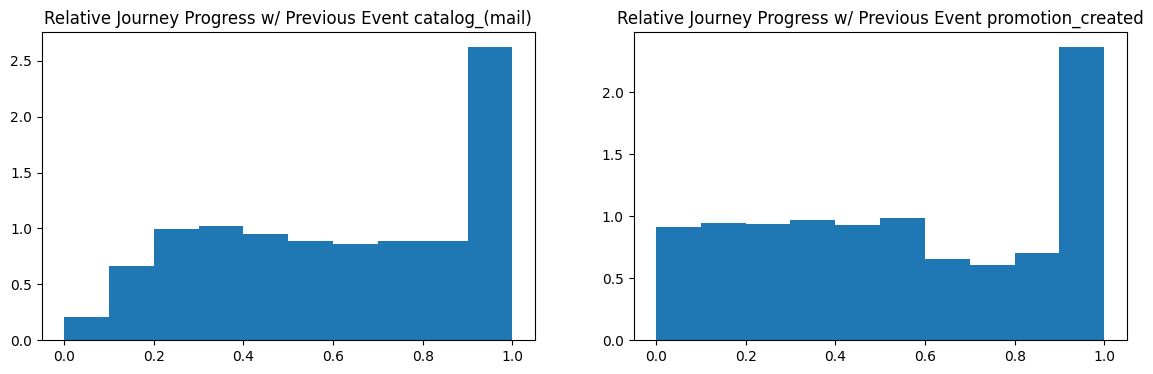

In [82]:
prev_events = ['catalog_(mail)', 'promotion_created']

plt.figure(figsize=(14, 4))
for i, event in enumerate(prev_events):
    plt.subplot(1, 2, i+1)
    plt.hist(events_df_unsuccessful.loc[events_df_unsuccessful['previous_event'] == event, 'days_into_journey'] /
         events_df_unsuccessful.loc[events_df_unsuccessful['previous_event'] == event, 'days_in_journey'],
         density=True
    )
    plt.title(f'Relative Journey Progress w/ Previous Event {event}')

plt.show()

In [41]:
unsuccessful_events_grouped = events_df_unsuccessful.groupby(['previous_event', 'next_event'])
display(unsuccessful_events_grouped['time_delta_previous'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=10))
display(unsuccessful_events_grouped['time_delta_next'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=10))

count       mean     median  \
previous_event        next_event                                         
promotion_created     catalog_(mail)     2077068  12.112967  10.556424   
                      promotion_created  1935901  22.430925  19.013021   
catalog_(mail)        promotion_created  1375336  28.758785  23.987176   
                      catalog_(mail)      894066  24.147698  22.884711   
promotion_created     None                717917  43.979957  32.003657   
browse_products       promotion_created   636841  11.816050   6.439572   
catalog_(mail)        None                503697  28.669045  15.505428   
browse_products       browse_products     463004   2.692799   0.022859   
                      catalog_(mail)      422635  15.905040  14.513704   
campaignemail_clicked promotion_created   399338  17.766642  12.240810   

                                                 var  
previous_event        next_event                      
promotion_created     catalog_(mail)      369.870118  
                      promotion_created   766.376077  
catalog_(mail)        promotion_created   820.677180  
                      catalog_(mail)      695.711664  
promotion_created     None               2090.647618  
browse_products       promotion_created   382.111129  
catalog_(mail)        None               1147.020057  
browse_products       browse_products     255.992373  
                      catalog_(mail)      283.111287  
campaignemail_clicked promotion_created   401.197303

count       mean     median  \
previous_event           next_event                                         
promotion_created        catalog_(mail)     2077068   5.274935   2.488437   
                         promotion_created  1935901  26.528960  20.789005   
catalog_(mail)           promotion_created  1375336  21.017173  13.443079   
                         catalog_(mail)      894066  13.503331   6.033947   
browse_products          promotion_created   636841  12.977393  10.548264   
                         browse_products     463004   6.167324   1.108912   
                         catalog_(mail)      422635   5.913363   3.977558   
campaignemail_clicked    promotion_created   399338  13.458987  10.554676   
                         catalog_(mail)      361628   5.359004   3.977211   
application_web_approved promotion_created   262038  19.268701  17.473368   

                                                    var  
previous_event           next_event                      
promotion_created        catalog_(mail)       51.949222  
                         promotion_created  1233.414250  
catalog_(mail)           promotion_created   710.344902  
                         catalog_(mail)      217.384123  
browse_products          promotion_created   293.702233  
                         browse_products     307.744871  
                         catalog_(mail)       52.462394  
campaignemail_clicked    promotion_created   406.986773  
                         catalog_(mail)       44.845521  
application_web_approved promotion_created   491.739246

In [53]:
successful_events_grouped['time_delta_next'].agg(["count", "median"]).sort_values(by="median").head(n=10)

,,count,median
previous_event,next_event,,
application_web_submit,promotion_created,355,0.000012
add_to_cart,add_to_cart,143,0.000370
pre-application_(3rd_party_affiliates),application_web_view,19,0.000370
campaign_click,application_web_submit,20,0.000388
application_web_approved,begin_checkout,367,0.000405
add_to_cart,view_cart,9372,0.000417
application_web_view,application_web_submit,41,0.000475
account_downpaymentreceived,view_cart,3,0.000567
browse_products,add_to_cart,704,0.000602


In [54]:
unsuccessful_events_grouped['time_delta_next'].agg(["count", "median"]).sort_values(by="median").head(n=10)

,,count,median
previous_event,next_event,,
account_downpaymentreceived,promotion_created,3,0.000012
application_phone_declined,promotion_created,1,0.000012
browse_products,add_to_cart,6806,0.000046
site_registration,application_web_submit,2,0.000197
add_to_cart,view_cart,100231,0.000266
pre-application_(3rd_party_affiliates),application_web_submit,13,0.000278
application_web_view,application_web_submit,251,0.000336
application_web_pending,view_cart,1,0.000359
application_web_approved,begin_checkout,4872,0.000382


In [46]:
events_df_successful[['previous_event', 'next_event']].value_counts(normalize=True)[:10]

previous_event     next_event       
promotion_created  catalog_(mail)       0.092766
browse_products    browse_products      0.078409
promotion_created  promotion_created    0.068776
browse_products    promotion_created    0.049747
catalog_(mail)     promotion_created    0.047699
promotion_created  None                 0.032363
browse_products    catalog_(mail)       0.031910
catalog_(mail)     catalog_(mail)       0.029514
promotion_created  browse_products      0.029217
catalog_(mail)     None                 0.023487
Name: proportion, dtype: float64

In [47]:
events_df_unsuccessful[['previous_event', 'next_event']].value_counts(normalize=True)[:10]

previous_event         next_event       
promotion_created      catalog_(mail)       0.147624
                       promotion_created    0.137591
catalog_(mail)         promotion_created    0.097749
                       catalog_(mail)       0.063544
promotion_created      None                 0.051025
browse_products        promotion_created    0.045262
catalog_(mail)         None                 0.035799
browse_products        browse_products      0.032907
                       catalog_(mail)       0.030038
campaignemail_clicked  promotion_created    0.028382
Name: proportion, dtype: float64

## Time Series Analysis

In [125]:
df = pd.read_parquet("data/train_data2_flattened.parquet")

In [109]:
df.head()

,id,events,event_names,timestamps,journey_length
0,-1000001271 551641434,"[12, 4, 19, 19, 19, 2, 4]","[application_web_approved, browse_products, ap...","[2022-10-31T13:45:59.000000, 2022-10-31T13:47:...",7
1,-100000293 92584960,"[12, 4, 4, 4, 4, 4, 4, 4, 11, 4, 4, 11, 4, 11,...","[application_web_approved, browse_products, br...","[2021-11-11T01:30:43.000000, 2021-11-11T01:39:...",31
2,-100001025 -1674572031,"[2, 19, 1, 19, 19, 19, 19, 19, 19, 19, 3, 19, ...","[campaign_click, application_web_view, promoti...","[2022-05-09T06:00:00.000000, 2022-05-09T13:10:...",26
3,-1000011207 -1448136887,"[12, 4, 11, 5, 5, 5, 4, 5, 4, 4, 4, 4, 1, 4, 4...","[application_web_approved, browse_products, ad...","[2021-03-21T11:19:48.000000, 2021-03-21T11:27:...",61
4,-100001164 -1710062169,[15],[application_phone_approved],[2022-12-02T07:45:16.000000],1


In [110]:
start_dates = []
journey_lengths = []
num_promotions = []
days_to_first_promotion = []
is_successful = []

for row in df.itertuples(index=False):
    start_dates.append(row.timestamps[0].astype('datetime64[D]'))
    journey_lengths.append((row.timestamps[-1] - row.timestamps[0]) / np.timedelta64(1, 'D'))
    num_promotions.append((row.event_names == 'promotion_created').sum())
    promotion_event_indices = np.where(row.event_names == 'promotion_created')[0]
    if len(promotion_event_indices) > 0:
        days_to_first_promotion.append((row.timestamps[promotion_event_indices[0]] - row.timestamps[0]) / np.timedelta64(1, 'D'))
    else:
        days_to_first_promotion.append(np.nan)

    is_successful.append('order_shipped' in row.event_names)

In [111]:
journey_info = pd.DataFrame(
    {
        'start_date': start_dates,
        'journey_length_days': journey_lengths,
        'num_promotions': num_promotions,
        'days_to_first_promotion': days_to_first_promotion,
        'successful': is_successful
    }
)

In [113]:
journey_info = journey_info[journey_info['start_date'] >= '2021-01-01']

In [114]:
journey_info.head()

,start_date,journey_length_days,num_promotions,days_to_first_promotion,successful
0,2022-10-31,33.199630,0,NaN,False
1,2021-11-11,202.238125,7,36.959468,False
2,2022-05-09,34.750000,3,0.299086,False
3,2021-03-21,33.094456,3,0.042731,False
4,2022-12-02,0.000000,0,NaN,False


In [117]:
average_lengths = journey_info.groupby('start_date')['journey_length_days'].mean().resample('MS').mean()

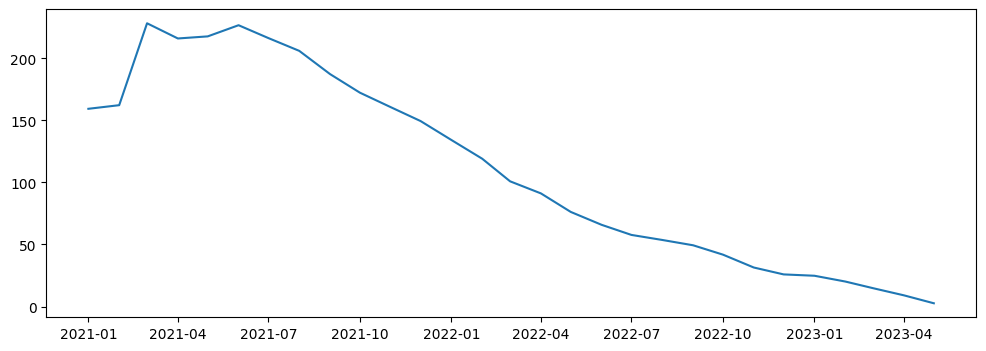

In [123]:
plt.figure(figsize=(12, 4))
plt.plot(average_lengths.index, average_lengths)
plt.show()

In [7]:
average_promos = journey_info.groupby('start_date')['num_promotions'].mean()

In [8]:
total_promos = journey_info.groupby('start_date')['num_promotions'].sum().resample('MS').sum()

In [9]:
total_journeys = journey_info.groupby('start_date')['num_promotions'].count().resample('MS').sum()

In [10]:
total_journeys.head()

start_date
2021-01-01    69904
2021-02-01    72723
2021-03-01    88677
2021-04-01    80598
2021-05-01    77467
Freq: MS, Name: num_promotions, dtype: int64

In [11]:
total_promos.head()

start_date
2021-01-01    365786
2021-02-01    400804
2021-03-01    560932
2021-04-01    481877
2021-05-01    479998
Freq: MS, Name: num_promotions, dtype: int64

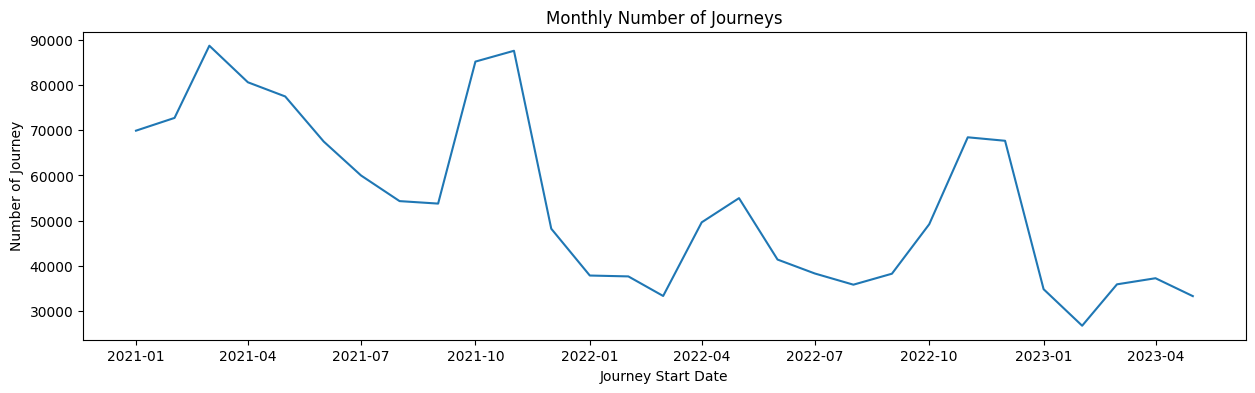

In [12]:
plt.figure(figsize=(15, 4))
plt.plot(total_journeys.index, total_journeys)
plt.xlabel('Journey Start Date')
plt.ylabel('Number of Journey')
plt.title('Monthly Number of Journeys')
plt.show()

In [13]:
successful_journeys = journey_info.groupby('start_date')['successful'].sum().resample('MS').sum()

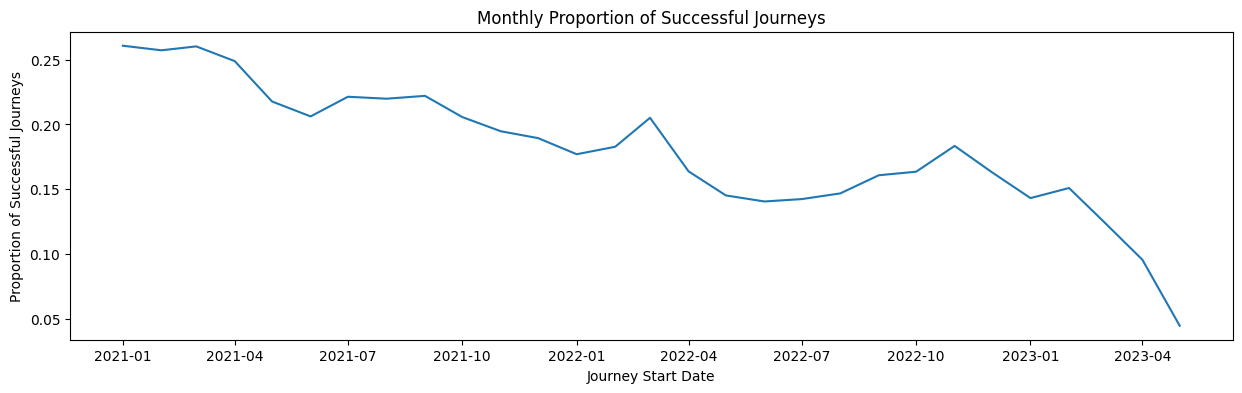

In [14]:
plt.figure(figsize=(15, 4))
plt.plot(total_journeys.index, successful_journeys / total_journeys)
plt.xlabel('Journey Start Date')
plt.ylabel('Proportion of Successful Journeys')
plt.title('Monthly Proportion of Successful Journeys')
plt.show()

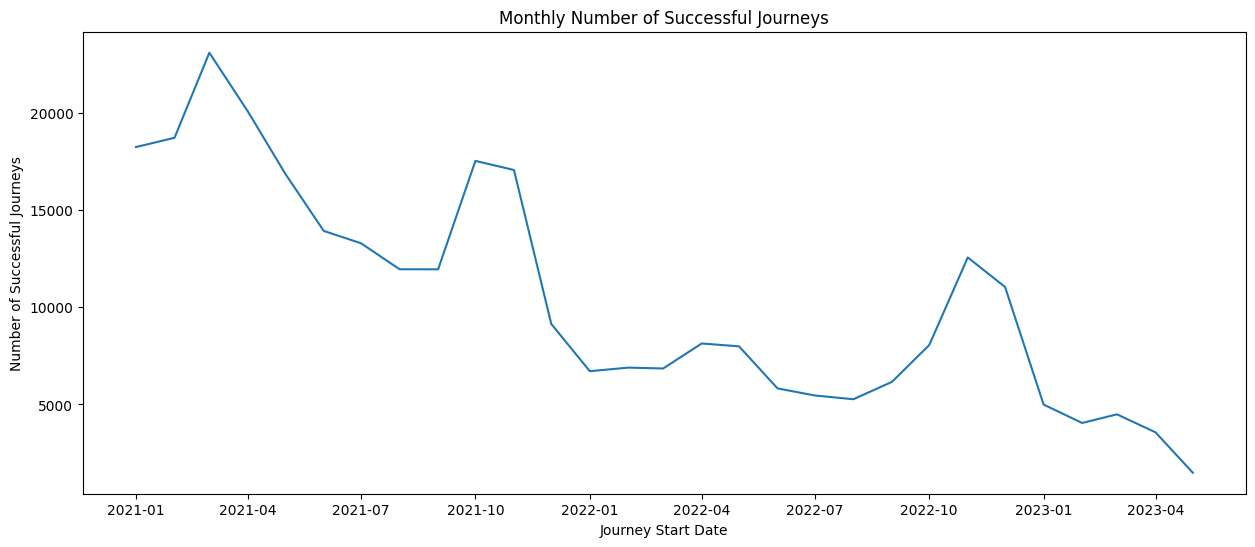

In [15]:
plt.figure(figsize=(15, 6))
plt.plot(successful_journeys.index, successful_journeys)
plt.xlabel('Journey Start Date')
plt.ylabel('Number of Successful Journeys')
plt.title('Monthly Number of Successful Journeys')
plt.show()

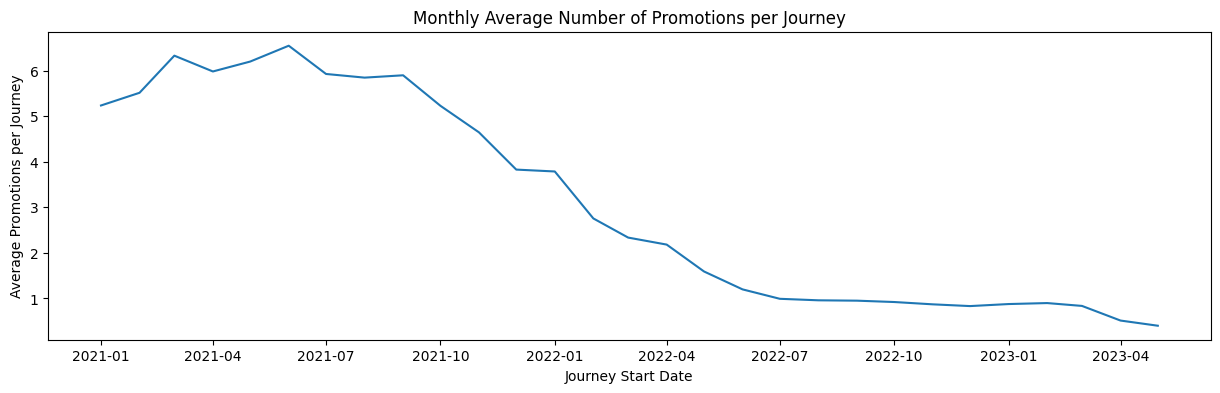

In [16]:
plt.figure(figsize=(15, 4))
plt.plot(total_journeys.index, total_promos / total_journeys)
plt.xlabel('Journey Start Date')
plt.ylabel('Average Promotions per Journey')
plt.title('Monthly Average Number of Promotions per Journey')
plt.show()

In [17]:
no_promo_counts = journey_info.groupby('start_date')['days_to_first_promotion'].apply(lambda x: x.isna().sum()).resample('MS').sum()

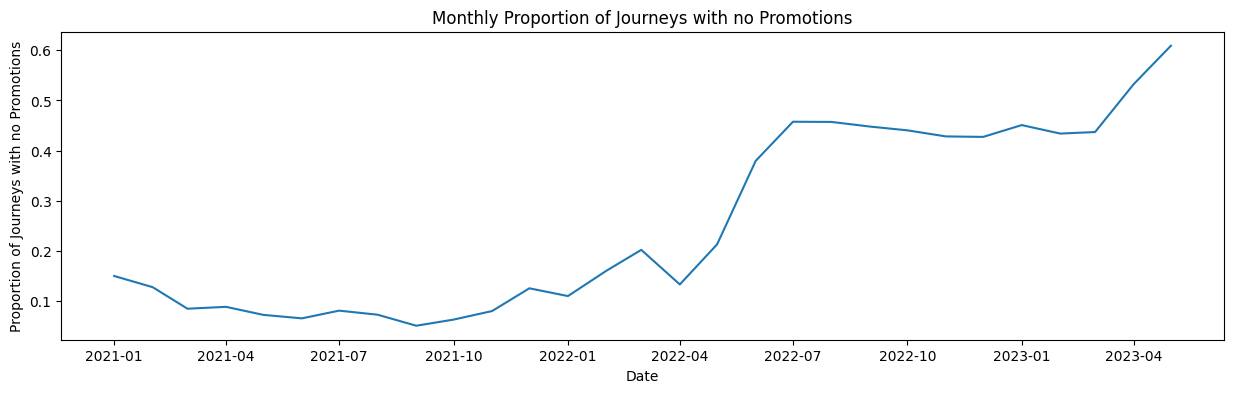

In [18]:
plt.figure(figsize=(15, 4))
plt.plot(total_journeys.index, no_promo_counts / total_journeys)
plt.xlabel('Date')
plt.ylabel('Proportion of Journeys with no Promotions')
plt.title('Monthly Proportion of Journeys with no Promotions')
plt.show()

In [19]:
successful_journeys_no_promo = journey_info[journey_info['successful']].groupby('start_date')['days_to_first_promotion'].apply(lambda x: x.isna().sum()).resample('MS').sum()

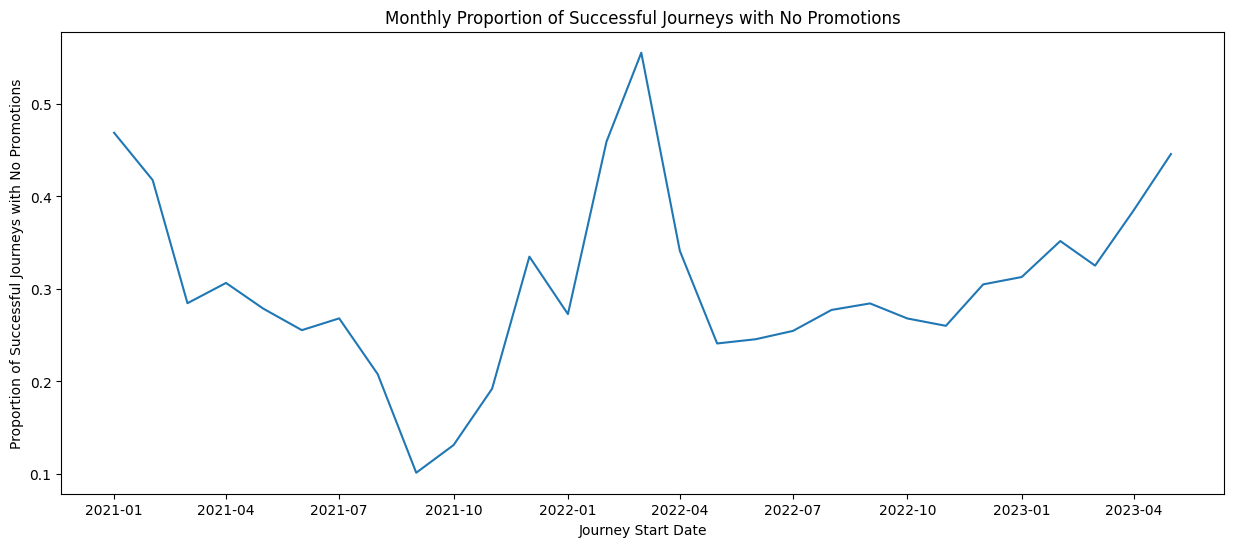

In [20]:
plt.figure(figsize=(15, 6))
plt.plot(successful_journeys.index, successful_journeys_no_promo / successful_journeys)
plt.xlabel('Journey Start Date')
plt.ylabel('Proportion of Successful Journeys with No Promotions')
plt.title('Monthly Proportion of Successful Journeys with No Promotions')
plt.show()

In [21]:
total_promos_successful_journeys_exclude_none = journey_info[(journey_info['successful']) & ~(journey_info['days_to_first_promotion'].isna())].groupby('start_date')['num_promotions'].sum().resample('MS').sum()

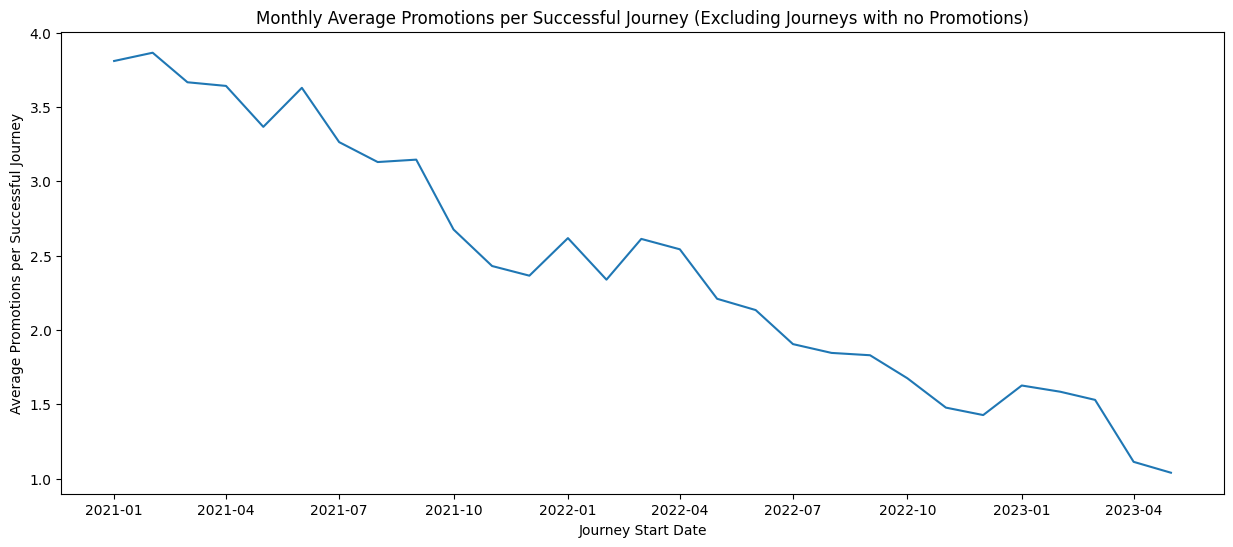

In [22]:
plt.figure(figsize=(15, 6))
plt.plot(successful_journeys.index, total_promos_successful_journeys_exclude_none / (successful_journeys - successful_journeys_no_promo))
plt.xlabel('Journey Start Date')
plt.ylabel('Average Promotions per Successful Journey')
plt.title('Monthly Average Promotions per Successful Journey (Excluding Journeys with no Promotions)')
plt.show()

In [23]:
total_promos_successful_journeys = journey_info[journey_info['successful']].groupby('start_date')['num_promotions'].sum().resample('MS').sum()

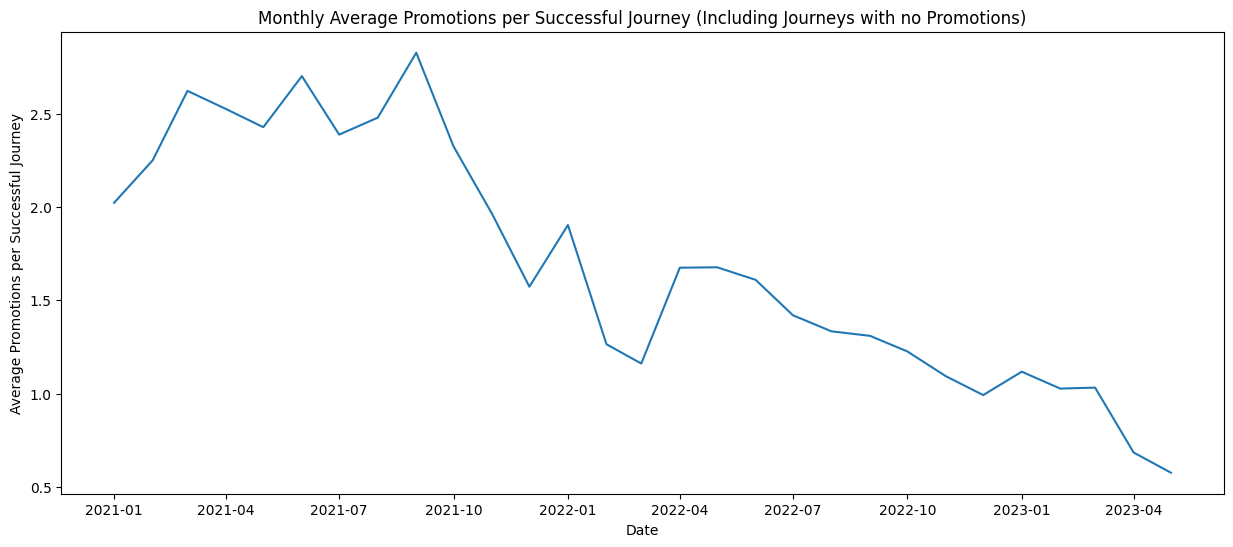

In [24]:
plt.figure(figsize=(15, 6))
plt.plot(successful_journeys.index, total_promos_successful_journeys / successful_journeys)
plt.xlabel('Date')
plt.ylabel('Average Promotions per Successful Journey')
plt.title('Monthly Average Promotions per Successful Journey (Including Journeys with no Promotions)')
plt.show()

In [25]:
unsuccessful_journeys = journey_info[~journey_info['successful']].groupby('start_date')['successful'].count().resample('MS').sum()

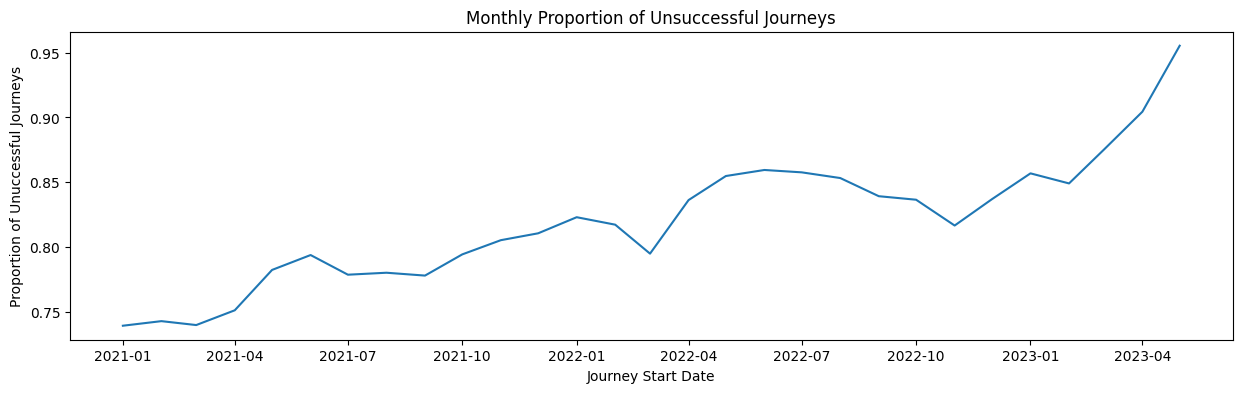

In [26]:
plt.figure(figsize=(15, 4))
plt.plot(total_journeys.index, unsuccessful_journeys / total_journeys)
plt.xlabel('Journey Start Date')
plt.ylabel('Proportion of Unuccessful Journeys')
plt.title('Monthly Proportion of Unsuccessful Journeys')
plt.show()

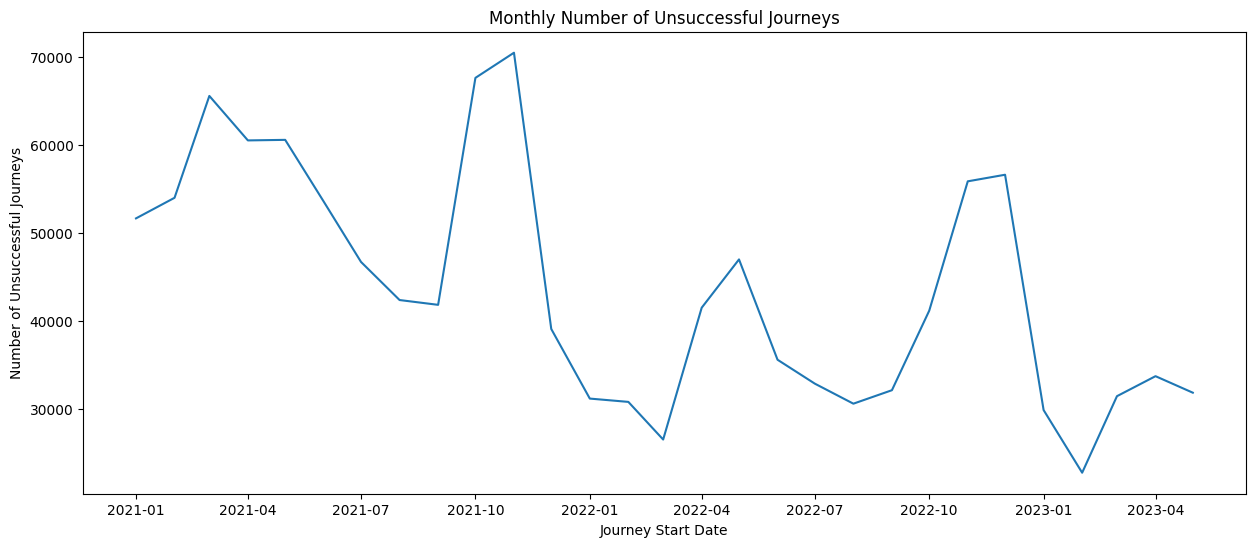

In [27]:
plt.figure(figsize=(15, 6))
plt.plot(unsuccessful_journeys.index, unsuccessful_journeys)
plt.xlabel('Journey Start Date')
plt.ylabel('Number of Unsuccessful Journeys')
plt.title('Monthly Number of Unsuccessful Journeys')
plt.show()

In [28]:
unsuccessful_journeys_no_promo = journey_info[~journey_info['successful']].groupby('start_date')['days_to_first_promotion'].apply(lambda x: x.isna().sum()).resample('MS').sum()

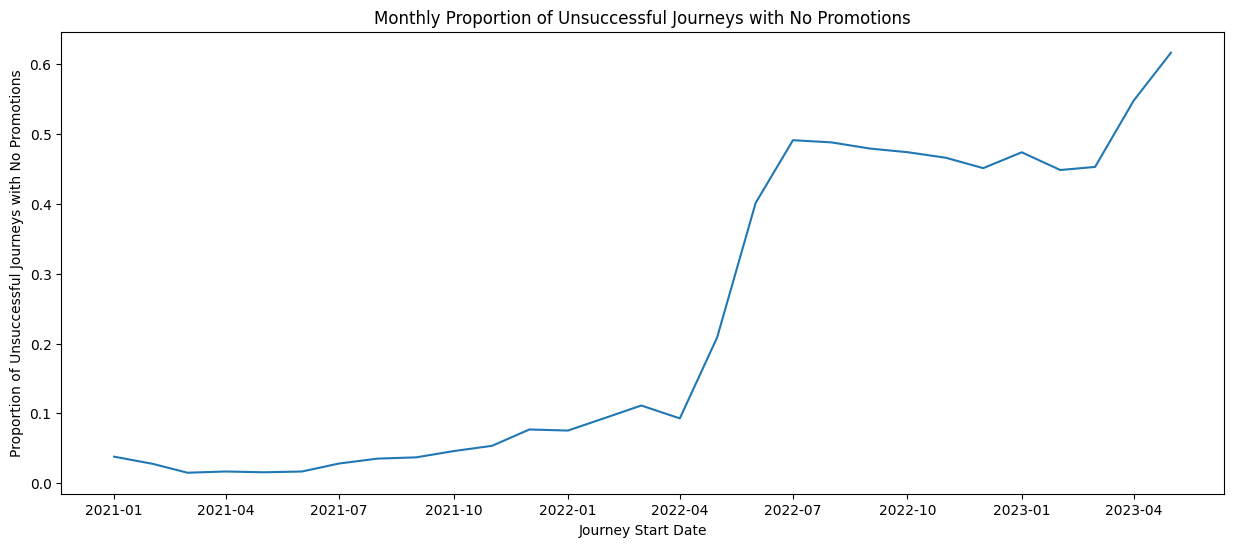

In [29]:
plt.figure(figsize=(15, 6))
plt.plot(unsuccessful_journeys.index, unsuccessful_journeys_no_promo / unsuccessful_journeys)
plt.xlabel('Journey Start Date')
plt.ylabel('Proportion of Unsuccessful Journeys with No Promotions')
plt.title('Monthly Proportion of Unsuccessful Journeys with No Promotions')
plt.show()

In [30]:
total_promos_unsuccessful_journeys_exclude_none = journey_info[(~journey_info['successful']) & ~(journey_info['days_to_first_promotion'].isna())].groupby('start_date')['num_promotions'].sum().resample('MS').sum()

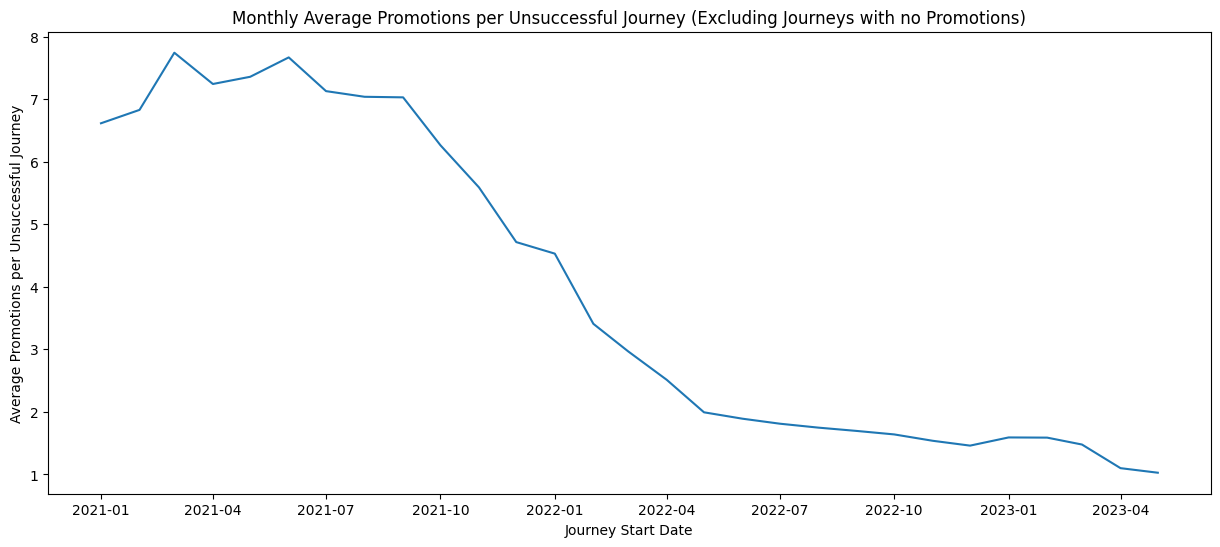

In [31]:
plt.figure(figsize=(15, 6))
plt.plot(unsuccessful_journeys.index, total_promos_unsuccessful_journeys_exclude_none / (unsuccessful_journeys - unsuccessful_journeys_no_promo))
plt.xlabel('Journey Start Date')
plt.ylabel('Average Promotions per Unsuccessful Journey')
plt.title('Monthly Average Promotions per Unsuccessful Journey (Excluding Journeys with no Promotions)')
plt.show()

In [32]:
total_promos_unsuccessful_journeys = journey_info[~journey_info['successful']].groupby('start_date')['num_promotions'].sum().resample('MS').sum()

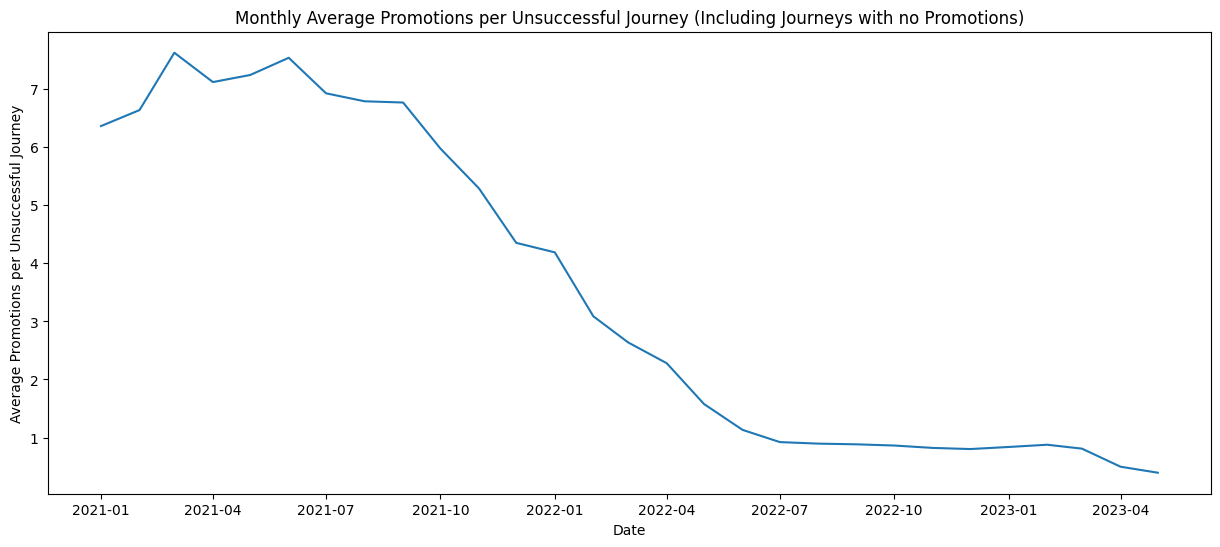

In [33]:
plt.figure(figsize=(15, 6))
plt.plot(unsuccessful_journeys.index, total_promos_unsuccessful_journeys / unsuccessful_journeys)
plt.xlabel('Date')
plt.ylabel('Average Promotions per Unsuccessful Journey')
plt.title('Monthly Average Promotions per Unsuccessful Journey (Including Journeys with no Promotions)')
plt.show()

## Revisiting Pre- and Post-Promotion Events

Now that it is clear that there was a big shift in Fingerhut's promotion strategy between early 2021 (when most journeys had about 7 promotions each) to 2022 (when most journeys had only 1 promotion each), let's redo our initial analysis, segmenting the data by date.

* The average number of promotions seems to be pretty stable from January 2021 until October 2021. This will be the first set of data we look at.
* There then seems to be a transition period between October 2021 until July 2022. This will be the second set.
* Finally, the number of promotions seems to stabilize (at least among unsuccessful journeys) in July 2022 until the end of the dataset. This will be the third set we analyze.


In [3]:
df = pd.read_parquet("data/training_data.parquet")

In [4]:
df.head()

,id,events,event_names,timestamps,journey_length,outcome,start_timestamp,end_timestamp,current_datetime
0,-1005528678 -2059117939,"[12, 4, 4, 4, 1, 1, 21, 1]","[application_web_approved, browse_products, br...","[2021-06-10T10:16:43.000000, 2021-06-10T10:18:...",8,unsuccessful,2021-06-10 10:16:43+00:00,2022-06-11 12:16:15+00:00,2021-08-20 03:23:36+00:00
1,550319820 1907517993,"[22, 2, 12, 1, 24, 24, 24, 24, 1, 21, 1, 1, 21...","[pre-application_(3rd_party_affiliates), campa...","[2021-11-24T06:00:00.000000, 2021-11-24T06:00:...",14,unsuccessful,2021-11-24 06:00:00+00:00,2022-09-12 12:07:39+00:00,2022-05-10 21:58:34+00:00
2,-931437166 -273076191,"[2, 19, 19, 19, 19, 19, 19, 19, 3, 12, 4, 4, 4...","[campaign_click, application_web_view, applica...","[2021-11-16T06:00:00.000000, 2021-11-16T18:27:...",58,unsuccessful,2021-11-16 06:00:00+00:00,2022-08-12 00:00:00+00:00,2022-08-06 21:35:26+00:00
3,-1633366293 2048161844,"[12, 4, 11, 5, 1]","[application_web_approved, browse_products, ad...","[2022-06-20T06:29:48.000000, 2022-06-20T06:32:...",5,unsuccessful,2022-06-20 06:29:48+00:00,2022-08-19 07:04:43+00:00,2022-08-06 21:35:26+00:00
4,14655434 -620023259,"[19, 19, 19, 19, 19, 19, 3, 19, 12, 4]","[application_web_view, application_web_view, a...","[2022-04-22T12:50:44.000000, 2022-04-22T12:50:...",10,unsuccessful,2022-04-22 12:50:44+00:00,2022-12-15 12:17:12+00:00,2022-08-06 21:35:26+00:00


### Analysis Until October 2021

In [5]:
end_cutoff = pd.Timestamp('2021-10-01', tz='UTC')

In [17]:
event_numbers = []
journey_times = []
journey_lengths = []
journey_time_proportions = []
previous_events = []
previous_time_diffs = []
next_events = []
next_time_diffs = []

for i, row in enumerate(df[(df['start_timestamp'] < end_cutoff) & (df['outcome'] == 'successful')].itertuples(index=False)):
    promotion_indices = np.where(row.event_names == 'promotion_created')[0]

    if len(promotion_indices) > 0:
        event_numbers.extend(promotion_indices + 1)
        journey_times.extend((row.timestamps[promotion_indices] - row.timestamps[0]) / np.timedelta64(1, 'D'))
        journey_lengths.extend(len(promotion_indices) * [(row.timestamps[-1] - row.timestamps[0]) / np.timedelta64(1, 'D')])
        journey_time_proportions.extend((promotion_indices + 1) / len(row.event_names))
        previous_indices = promotion_indices - 1
        previous_events.extend(row.event_names[previous_indices])
        previous_time_diffs.extend((row.timestamps[promotion_indices] - row.timestamps[previous_indices]) / np.timedelta64(1, 'D'))

        next_indices = promotion_indices + 1
        if next_indices[-1] < len(row.event_names):
            next_events.extend(row.event_names[next_indices])
        else:
            next_events.extend(np.append(row.event_names[next_indices[:len(next_indices) - 1]], 'None'))

        if next_indices[-1] < len(row.event_names):
            next_time_diffs.extend((row.timestamps[next_indices] - row.timestamps[promotion_indices]) / np.timedelta64(1, 'D'))
        else:
            next_time_diffs.extend(np.append((row.timestamps[next_indices[:len(next_indices) - 1]] - row.timestamps[promotion_indices[:len(promotion_indices) - 1]]) / np.timedelta64(1, 'D'), np.nan))


events_df_successful = pd.DataFrame({
    'event_number': event_numbers,
    'days_into_journey': journey_times,
    'days_in_journey': journey_lengths,
    'relative_event_progress_through_journey': journey_time_proportions,
    'previous_event': previous_events,
    'time_delta_previous': previous_time_diffs,
    'next_event': next_events,
    'time_delta_next': next_time_diffs
})

In [20]:
events_df_successful.tail()

,event_number,days_into_journey,days_in_journey,relative_event_progress_through_journey,previous_event,time_delta_previous,next_event,time_delta_next
411355,43,47.152442,161.828125,0.682540,campaignemail_clicked,10.477674,promotion_created,0.185150
411356,44,47.337593,161.828125,0.698413,promotion_created,0.185150,promotion_created,10.566782
411357,45,57.904375,161.828125,0.714286,promotion_created,10.566782,browse_products,0.023472
411358,52,88.122558,161.828125,0.825397,catalog_(mail),1.294433,catalog_(mail),26.705567
411359,54,138.815197,161.828125,0.857143,catalog_(mail),23.987072,catalog_(mail),11.012928


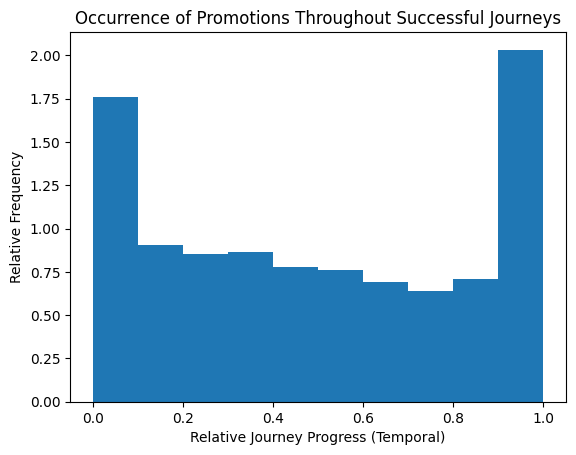

In [21]:
plt.hist(events_df_successful['days_into_journey'] / events_df_successful['days_in_journey'], density=True)
plt.xlabel('Relative Journey Progress (Temporal)')
plt.ylabel('Relative Frequency')
plt.title('Occurrence of Promotions Throughout Successful Journeys')
plt.show()

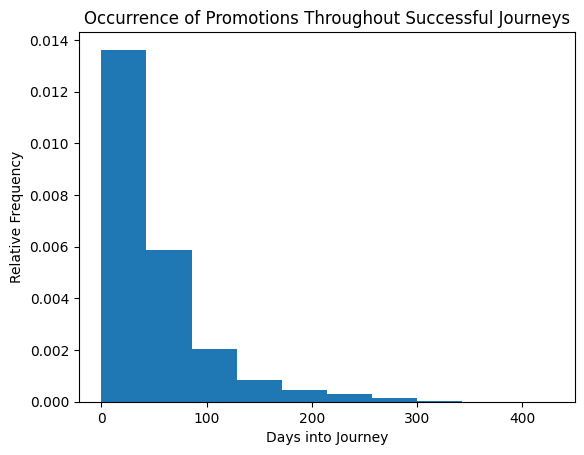

In [66]:
plt.hist(events_df_successful['days_into_journey'], density=True)
plt.xlabel('Days into Journey')
plt.ylabel('Relative Frequency')
plt.title('Occurrence of Promotions Throughout Successful Journeys')
plt.show()

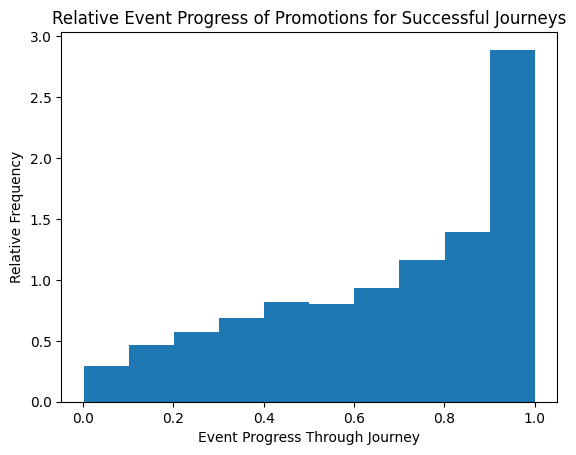

In [67]:
plt.hist(events_df_successful['relative_event_progress_through_journey'], density=True)
plt.xlabel('Event Progress Through Journey')
plt.ylabel('Relative Frequency')
plt.title('Relative Event Progress of Promotions for Successful Journeys')
plt.show()

In [7]:
events_df_successful.groupby('previous_event')['time_delta_previous'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=12)

,count,mean,median,var
previous_event,,,,
promotion_created,125024,11.438477,3.632106,453.050081
browse_products,91268,5.108418,0.029896,196.949463
catalog_(mail),59592,14.102752,4.311481,531.389285
campaignemail_clicked,34845,10.133077,7.561794,221.986048
begin_checkout,32581,2.725046,0.021470,128.873561
view_cart,32190,3.363519,0.022095,175.680384
application_web_approved,12809,10.432366,5.808935,239.174095
add_to_cart,8453,1.078666,0.021424,89.346786
application_web_view,6224,7.896423,0.828339,312.644947


We see a few different types of promotions here:

1. First are promotions that are likely triggered by user actions, such as browsing for products, beginning the checkout process, viewing the cart, and adding an item to the cart. The median time between these actions and when the promo is generated is about 30 minutes.

2. Second are promotions that are likely trying to re-engage users after not interacting with the platform for a while. The most common previous event is another promotion that was sent a few days to a few weeks prior to the current promotion. Other common previous events with similar time windows are catalog_mail and campaignemail_clicked, which are examples of other kinds of promotions or incentives to try to get the user to interact with the Fingerhut platform and make a purchase.

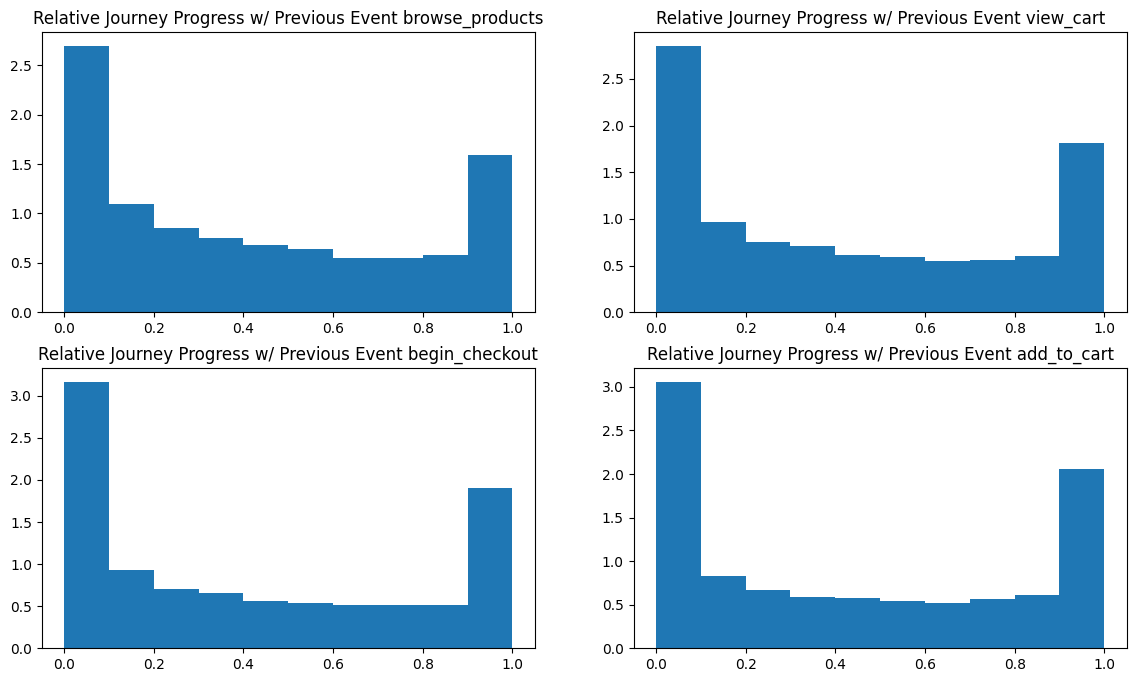

In [37]:
prev_events = ['browse_products', 'view_cart', 'begin_checkout', 'add_to_cart']

plt.figure(figsize=(14, 8))
for i, event in enumerate(prev_events):
    plt.subplot(2, 2, i+1)
    plt.hist(events_df_successful.loc[events_df_successful['previous_event'] == event, 'days_into_journey'] /
         events_df_successful.loc[events_df_successful['previous_event'] == event, 'days_in_journey'],
         density=True
    )
    plt.title(f'Relative Journey Progress w/ Previous Event {event}')

plt.show()

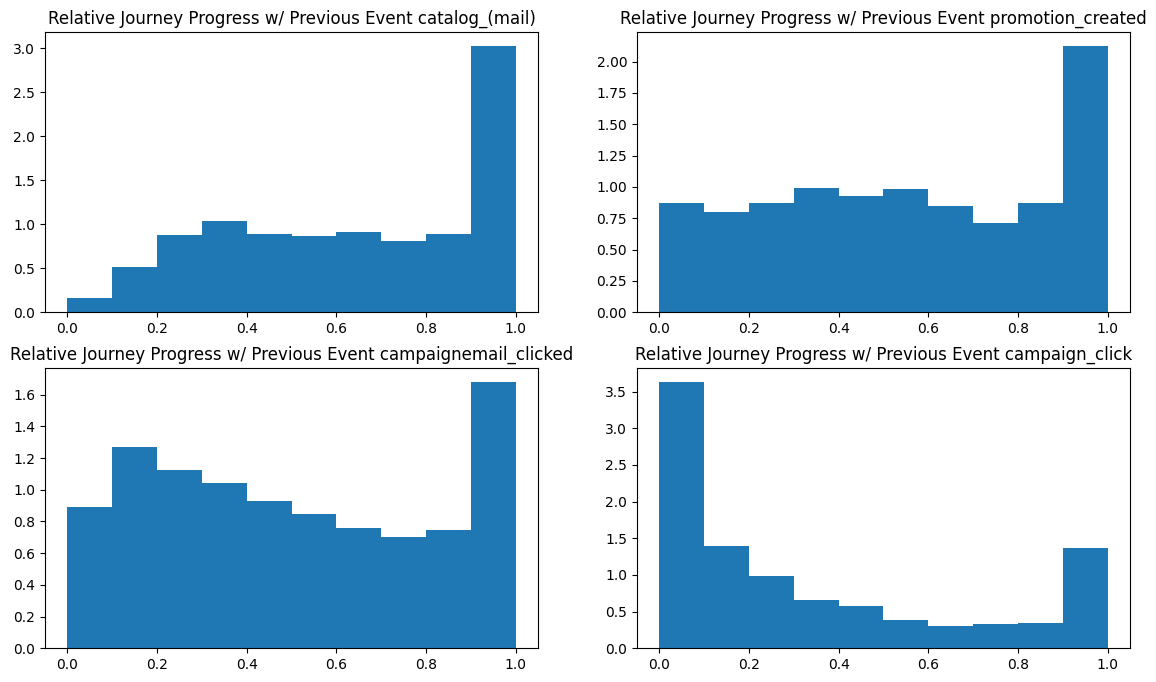

In [38]:
prev_events = ['catalog_(mail)', 'promotion_created', 'campaignemail_clicked', 'campaign_click']

plt.figure(figsize=(14, 8))
for i, event in enumerate(prev_events):
    plt.subplot(2, 2, i+1)
    plt.hist(events_df_successful.loc[events_df_successful['previous_event'] == event, 'days_into_journey'] /
         events_df_successful.loc[events_df_successful['previous_event'] == event, 'days_in_journey'],
         density=True
    )
    plt.title(f'Relative Journey Progress w/ Previous Event {event}')

plt.show()

In [68]:
successful_events_grouped = events_df_successful.groupby(['previous_event', 'next_event'])
display(successful_events_grouped['relative_event_progress_through_journey'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=10))
display(successful_events_grouped['time_delta_previous'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=12))
display(successful_events_grouped['time_delta_next'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=10))

count      mean    median       var
previous_event        next_event                                            
promotion_created     catalog_(mail)     43681  0.746794  0.823529  0.051584
                      promotion_created  40604  0.705976  0.777778  0.055346
browse_products       browse_products    27563  0.508706  0.500000  0.067780
                      promotion_created  23797  0.638857  0.687500  0.066454
catalog_(mail)        promotion_created  22100  0.758262  0.833333  0.043552
promotion_created     None               14795  1.000000  1.000000  0.000000
                      browse_products    13732  0.533267  0.545455  0.066836
browse_products       catalog_(mail)     13350  0.686428  0.733333  0.056122
catalog_(mail)        catalog_(mail)     11903  0.789277  0.866667  0.041598
campaignemail_clicked promotion_created  11439  0.670243  0.725000  0.056899

count       mean     median  \
previous_event        next_event                                       
promotion_created     catalog_(mail)     43681   8.477380   3.590775   
                      promotion_created  40604  13.816809   9.828137   
browse_products       browse_products    27563   2.225531   0.022905   
                      promotion_created  23797   6.946879   2.351204   
catalog_(mail)        promotion_created  22100  19.220058  21.300289   
promotion_created     None               14795  24.961487  19.195937   
                      browse_products    13732   7.504603   0.570775   
browse_products       catalog_(mail)     13350  12.695492  10.923947   
catalog_(mail)        catalog_(mail)     11903  18.045628  15.633565   
campaignemail_clicked promotion_created  11439  11.942866   9.093600   
catalog_(mail)        None               11405  13.223303   4.305868   
campaignemail_clicked catalog_(mail)      9621  12.290619  10.277465   

                                                var  
previous_event        next_event                     
promotion_created     catalog_(mail)     157.107675  
                      promotion_created  365.028976  
browse_products       browse_products    137.858116  
                      promotion_created  148.727237  
catalog_(mail)        promotion_created  435.008243  
promotion_created     None               731.762696  
                      browse_products    563.387389  
browse_products       catalog_(mail)     162.145410  
catalog_(mail)        catalog_(mail)     380.141418  
campaignemail_clicked promotion_created  167.440034  
catalog_(mail)        None               488.198740  
campaignemail_clicked catalog_(mail)     139.375590

count       mean     median  \
previous_event        next_event                                       
promotion_created     catalog_(mail)     43681   5.508116   5.068275   
                      promotion_created  40604  14.714769   3.586962   
browse_products       browse_products    27563   4.023003   0.950833   
                      promotion_created  23797   9.045444   3.591030   
catalog_(mail)        promotion_created  22100  15.310067  18.370174   
promotion_created     browse_products    13732   9.788722   3.451979   
browse_products       catalog_(mail)     13350   5.392006   3.108316   
catalog_(mail)        catalog_(mail)     11903  13.519356   6.127269   
campaignemail_clicked promotion_created  11439   8.814767   3.588322   
                      catalog_(mail)      9621   4.818141   3.108275   

                                                var  
previous_event        next_event                     
promotion_created     catalog_(mail)      31.547787  
                      promotion_created  480.181391  
browse_products       browse_products     93.177379  
                      promotion_created  155.643407  
catalog_(mail)        promotion_created  336.190450  
promotion_created     browse_products    321.279955  
browse_products       catalog_(mail)      31.434551  
catalog_(mail)        catalog_(mail)     150.333476  
campaignemail_clicked promotion_created  191.036397  
                      catalog_(mail)      20.603324

In [39]:
event_numbers = []
journey_times = []
journey_lengths = []
journey_time_proportions = []
previous_events = []
previous_time_diffs = []
next_events = []
next_time_diffs = []

for i, row in enumerate(df[(df['start_timestamp'] < end_cutoff) & (df['outcome'] == 'unsuccessful')].itertuples(index=False)):
    promotion_indices = np.where(row.event_names == 'promotion_created')[0]

    if len(promotion_indices) > 0:
        event_numbers.extend(promotion_indices + 1)
        journey_times.extend((row.timestamps[promotion_indices] - row.timestamps[0]) / np.timedelta64(1, 'D'))
        journey_lengths.extend(len(promotion_indices) * [(row.timestamps[-1] - row.timestamps[0]) / np.timedelta64(1, 'D')])
        journey_time_proportions.extend((promotion_indices + 1) / len(row.event_names))
        previous_indices = promotion_indices - 1
        previous_events.extend(row.event_names[previous_indices])
        previous_time_diffs.extend((row.timestamps[promotion_indices] - row.timestamps[previous_indices]) / np.timedelta64(1, 'D'))

        next_indices = promotion_indices + 1
        if next_indices[-1] < len(row.event_names):
            next_events.extend(row.event_names[next_indices])
        else:
            next_events.extend(np.append(row.event_names[next_indices[:len(next_indices) - 1]], 'None'))

        if next_indices[-1] < len(row.event_names):
            next_time_diffs.extend((row.timestamps[next_indices] - row.timestamps[promotion_indices]) / np.timedelta64(1, 'D'))
        else:
            next_time_diffs.extend(np.append((row.timestamps[next_indices[:len(next_indices) - 1]] - row.timestamps[promotion_indices[:len(promotion_indices) - 1]]) / np.timedelta64(1, 'D'), np.nan))


events_df_unsuccessful = pd.DataFrame({
    'event_number': event_numbers,
    'days_into_journey': journey_times,
    'days_in_journey': journey_lengths,
    'relative_event_progress_through_journey': journey_time_proportions,
    'previous_event': previous_events,
    'time_delta_previous': previous_time_diffs,
    'next_event': next_events,
    'time_delta_next': next_time_diffs
})

In [42]:
events_df_unsuccessful.groupby('previous_event')['time_delta_previous'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=12)

,count,mean,median,var
previous_event,,,,
promotion_created,4443999,20.239765,10.565706,1114.375703
catalog_(mail),2288696,25.313355,21.872037,1115.218268
browse_products,1430016,8.554464,2.150104,358.098268
campaignemail_clicked,761095,15.334951,10.554201,476.018542
begin_checkout,450745,4.539701,0.021528,223.235296
view_cart,442373,5.893150,0.022870,303.683548
application_web_approved,396144,16.270434,12.924444,476.725840
application_web_view,140353,14.510841,10.757396,574.112511
add_to_cart,116384,1.656455,0.021319,75.263108


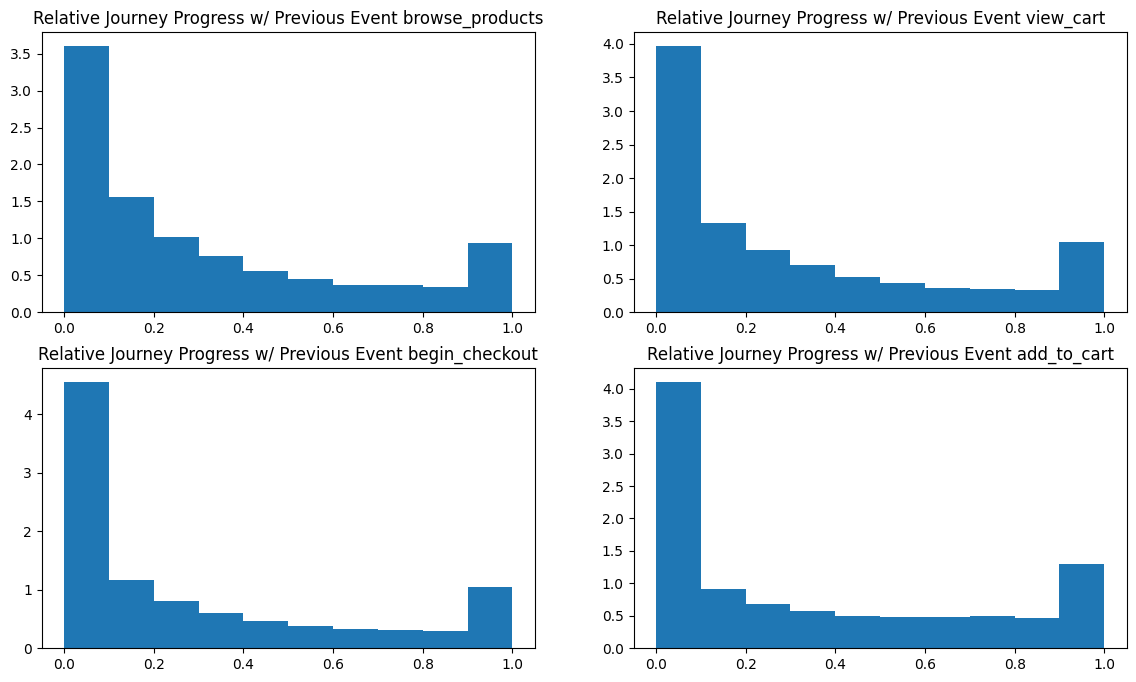

In [40]:
prev_events = ['browse_products', 'view_cart', 'begin_checkout', 'add_to_cart']

plt.figure(figsize=(14, 8))
for i, event in enumerate(prev_events):
    plt.subplot(2, 2, i+1)
    plt.hist(events_df_unsuccessful.loc[events_df_unsuccessful['previous_event'] == event, 'days_into_journey'] /
         events_df_unsuccessful.loc[events_df_unsuccessful['previous_event'] == event, 'days_in_journey'],
         density=True
    )
    plt.title(f'Relative Journey Progress w/ Previous Event {event}')

plt.show()

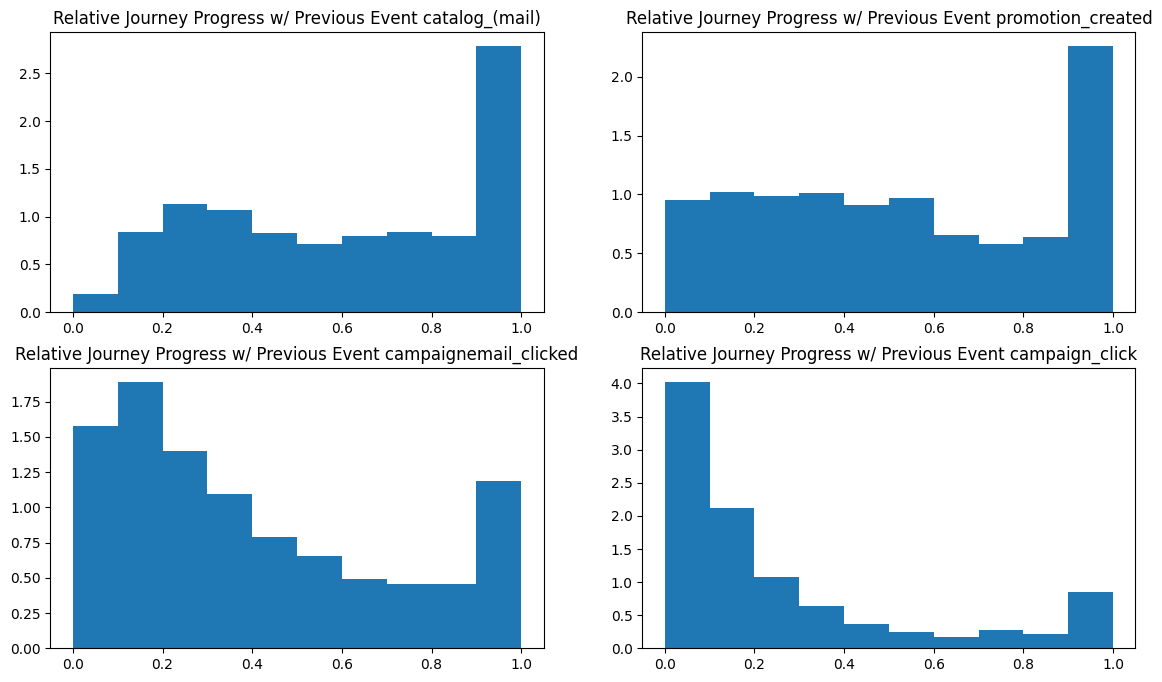

In [41]:
prev_events = ['catalog_(mail)', 'promotion_created', 'campaignemail_clicked', 'campaign_click']

plt.figure(figsize=(14, 8))
for i, event in enumerate(prev_events):
    plt.subplot(2, 2, i+1)
    plt.hist(events_df_unsuccessful.loc[events_df_unsuccessful['previous_event'] == event, 'days_into_journey'] /
         events_df_unsuccessful.loc[events_df_unsuccessful['previous_event'] == event, 'days_in_journey'],
         density=True
    )
    plt.title(f'Relative Journey Progress w/ Previous Event {event}')

plt.show()

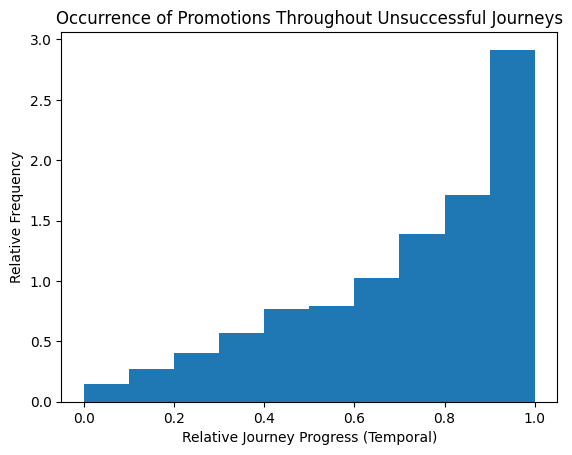

In [70]:
plt.hist(events_df_unsuccessful['relative_event_progress_through_journey'], density=True)
plt.xlabel('Relative Journey Progress (Temporal)')
plt.ylabel('Relative Frequency')
plt.title('Occurrence of Promotions Throughout Unsuccessful Journeys')
plt.show()

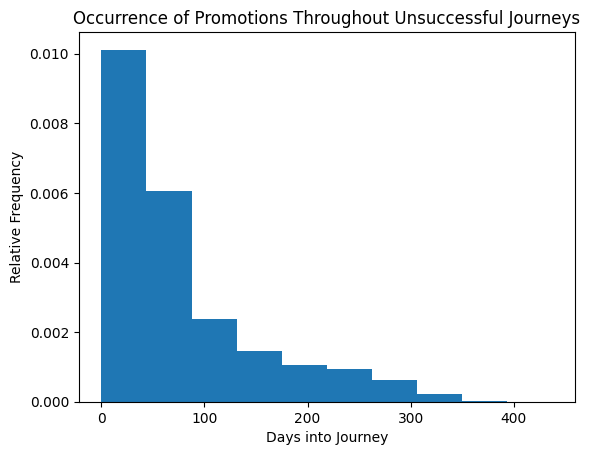

In [71]:
plt.hist(events_df_unsuccessful['days_into_journey'], density=True)
plt.xlabel('Days into Journey')
plt.ylabel('Relative Frequency')
plt.title('Occurrence of Promotions Throughout Unsuccessful Journeys')
plt.show()

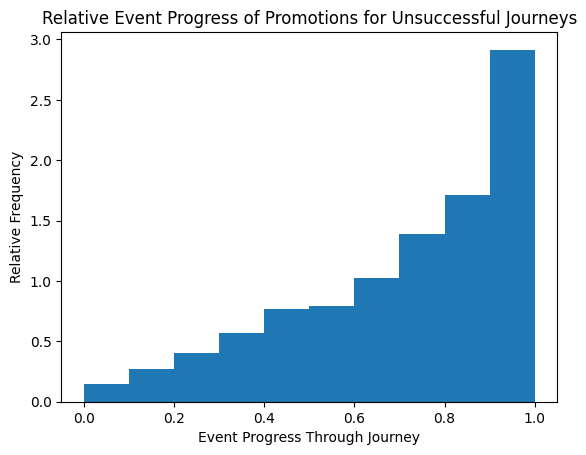

In [72]:
plt.hist(events_df_unsuccessful['relative_event_progress_through_journey'], density=True)
plt.xlabel('Event Progress Through Journey')
plt.ylabel('Relative Frequency')
plt.title('Relative Event Progress of Promotions for Unsuccessful Journeys')
plt.show()

In [73]:
unsuccessful_events_grouped = events_df_unsuccessful.groupby(['previous_event', 'next_event'])
display(unsuccessful_events_grouped['relative_event_progress_through_journey'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=10))
display(unsuccessful_events_grouped['time_delta_previous'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=10))
display(unsuccessful_events_grouped['time_delta_next'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=10))

count      mean    median       var
previous_event        next_event                                              
promotion_created     promotion_created  1847251  0.743020  0.800000  0.038205
                      catalog_(mail)     1582940  0.756432  0.818182  0.040268
catalog_(mail)        promotion_created  1054396  0.778042  0.828571  0.030766
                      catalog_(mail)      615372  0.800085  0.857143  0.030234
promotion_created     None                584817  1.000000  1.000000  0.000000
browse_products       promotion_created   521216  0.629879  0.666667  0.054295
catalog_(mail)        None                382569  1.000000  1.000000  0.000000
campaignemail_clicked promotion_created   322303  0.667571  0.708333  0.047971
browse_products       browse_products     318986  0.493072  0.480769  0.061434
                      catalog_(mail)      285137  0.670248  0.708333  0.050144

count       mean     median  \
previous_event        next_event                                         
promotion_created     promotion_created  1847251  22.161748  19.012975   
                      catalog_(mail)     1582940  11.762853   3.633831   
catalog_(mail)        promotion_created  1054396  27.543388  23.984711   
                      catalog_(mail)      615372  25.649811  21.877488   
promotion_created     None                584817  48.302346  32.003981   
browse_products       promotion_created   521216  10.190736   5.670584   
catalog_(mail)        None                382569  31.809996  19.294942   
campaignemail_clicked promotion_created   322303  15.844963  10.895810   
browse_products       browse_products     318986   2.696664   0.023056   
                      catalog_(mail)      285137  16.151799  14.372419   

                                                 var  
previous_event        next_event                      
promotion_created     promotion_created   751.327445  
                      catalog_(mail)      390.447861  
catalog_(mail)        promotion_created   925.772673  
                      catalog_(mail)      793.021240  
promotion_created     None               2378.340484  
browse_products       promotion_created   288.995636  
catalog_(mail)        None               1405.957218  
campaignemail_clicked promotion_created   373.463208  
browse_products       browse_products     225.811183  
                      catalog_(mail)      253.802699

count       mean     median  \
previous_event        next_event                                         
promotion_created     promotion_created  1847251  26.551235  19.013287   
                      catalog_(mail)     1582940   5.241279   3.108264   
catalog_(mail)        promotion_created  1054396  21.495098  18.373113   
                      catalog_(mail)      615372  12.462968   6.034421   
browse_products       promotion_created   521216  12.504938   4.999514   
campaignemail_clicked promotion_created   322303  13.409625   3.591447   
browse_products       browse_products     318986   4.904385   1.092222   
                      catalog_(mail)      285137   6.016340   3.121782   
campaignemail_clicked catalog_(mail)      249950   5.182183   3.108310   
promotion_created     browse_products     211510  14.286652   4.438519   

                                                 var  
previous_event        next_event                      
promotion_created     promotion_created  1280.498344  
                      catalog_(mail)       38.582013  
catalog_(mail)        promotion_created   866.957979  
                      catalog_(mail)      174.022116  
browse_products       promotion_created   308.839315  
campaignemail_clicked promotion_created   484.083793  
browse_products       browse_products     188.850074  
                      catalog_(mail)       45.208696  
campaignemail_clicked catalog_(mail)       29.086193  
promotion_created     browse_products     707.444787

In [74]:
successful_events_grouped['time_delta_next'].agg(["count", "median"]).sort_values(by="median").head(n=10)

,,count,median
previous_event,next_event,,
application_web_submit,application_web_view,124,0.000012
application_web_view,application_web_submit,23,0.000046
pre-application_(3rd_party_affiliates),application_web_view,15,0.000231
campaign_click,application_web_submit,20,0.000388
application_web_approved,begin_checkout,189,0.000394
application_web_view,application_web_view,1039,0.000509
account_downpaymentreceived,view_cart,2,0.000567
campaign_click,application_web_view,197,0.000995
account_downpaymentreceived,browse_products,1,0.001042


In [75]:
unsuccessful_events_grouped['time_delta_next'].agg(["count", "median"]).sort_values(by="median").head(n=10)

,,count,median
previous_event,next_event,,
account_downpaymentreceived,promotion_created,1,0.000012
site_registration,application_web_submit,2,0.000197
application_web_submit,application_web_view,1191,0.000197
pre-application_(3rd_party_affiliates),application_web_submit,13,0.000278
application_web_view,application_web_submit,236,0.000347
application_web_pending,view_cart,1,0.000359
application_web_approved,begin_checkout,1957,0.000370
campaign_click,application_web_submit,292,0.000567
add_to_cart,view_cart,27962,0.000706


In [76]:
events_df_successful[['previous_event', 'next_event']].value_counts(normalize=True)[:10]

previous_event         next_event       
promotion_created      catalog_(mail)       0.106187
                       promotion_created    0.098707
browse_products        browse_products      0.067005
                       promotion_created    0.057850
catalog_(mail)         promotion_created    0.053724
promotion_created      None                 0.035966
                       browse_products      0.033382
browse_products        catalog_(mail)       0.032453
catalog_(mail)         catalog_(mail)       0.028936
campaignemail_clicked  promotion_created    0.027808
Name: proportion, dtype: float64

In [77]:
events_df_unsuccessful[['previous_event', 'next_event']].value_counts(normalize=True)[:10]

previous_event         next_event       
promotion_created      promotion_created    0.173706
                       catalog_(mail)       0.148851
catalog_(mail)         promotion_created    0.099150
                       catalog_(mail)       0.057866
promotion_created      None                 0.054993
browse_products        promotion_created    0.049012
catalog_(mail)         None                 0.035975
campaignemail_clicked  promotion_created    0.030308
browse_products        browse_products      0.029996
                       catalog_(mail)       0.026813
Name: proportion, dtype: float64

### Analysis from October 2021 to July 2022

In [43]:
start_cutoff = pd.Timestamp('2021-10-01', tz='UTC')
end_cutoff = pd.Timestamp('2022-07-01', tz='UTC')

In [44]:
event_numbers = []
journey_times = []
journey_lengths = []
journey_time_proportions = []
previous_events = []
previous_time_diffs = []
next_events = []
next_time_diffs = []

for i, row in enumerate(df[(df['start_timestamp'] >= start_cutoff) & (df['start_timestamp'] < end_cutoff) & (df['outcome'] == 'successful')].itertuples(index=False)):
    promotion_indices = np.where(row.event_names == 'promotion_created')[0]

    if len(promotion_indices) > 0:
        event_numbers.extend(promotion_indices + 1)
        journey_times.extend((row.timestamps[promotion_indices] - row.timestamps[0]) / np.timedelta64(1, 'D'))
        journey_lengths.extend(len(promotion_indices) * [(row.timestamps[-1] - row.timestamps[0]) / np.timedelta64(1, 'D')])
        journey_time_proportions.extend((promotion_indices + 1) / len(row.event_names))
        previous_indices = promotion_indices - 1
        previous_events.extend(row.event_names[previous_indices])
        previous_time_diffs.extend((row.timestamps[promotion_indices] - row.timestamps[previous_indices]) / np.timedelta64(1, 'D'))

        next_indices = promotion_indices + 1
        if next_indices[-1] < len(row.event_names):
            next_events.extend(row.event_names[next_indices])
        else:
            next_events.extend(np.append(row.event_names[next_indices[:len(next_indices) - 1]], 'None'))

        if next_indices[-1] < len(row.event_names):
            next_time_diffs.extend((row.timestamps[next_indices] - row.timestamps[promotion_indices]) / np.timedelta64(1, 'D'))
        else:
            next_time_diffs.extend(np.append((row.timestamps[next_indices[:len(next_indices) - 1]] - row.timestamps[promotion_indices[:len(promotion_indices) - 1]]) / np.timedelta64(1, 'D'), np.nan))


events_df_successful = pd.DataFrame({
    'event_number': event_numbers,
    'days_into_journey': journey_times,
    'days_in_journey': journey_lengths,
    'relative_event_progress_through_journey': journey_time_proportions,
    'previous_event': previous_events,
    'time_delta_previous': previous_time_diffs,
    'next_event': next_events,
    'time_delta_next': next_time_diffs
})

In [45]:
events_df_successful.groupby('previous_event')['time_delta_previous'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=12)

,count,mean,median,var
previous_event,,,,
browse_products,40658,5.991914,0.035764,398.390735
promotion_created,32105,14.882980,10.559595,660.188260
catalog_(mail),24720,17.556847,15.504850,458.193982
begin_checkout,17471,3.419927,0.021574,344.115167
view_cart,16741,3.263476,0.022234,497.412801
add_to_cart,14443,0.447879,0.000012,17.815690
application_web_approved,11781,7.026400,0.000116,255.435904
campaignemail_clicked,10834,12.804159,9.835660,458.157928
application_web_view,2427,9.204887,2.721910,491.213463


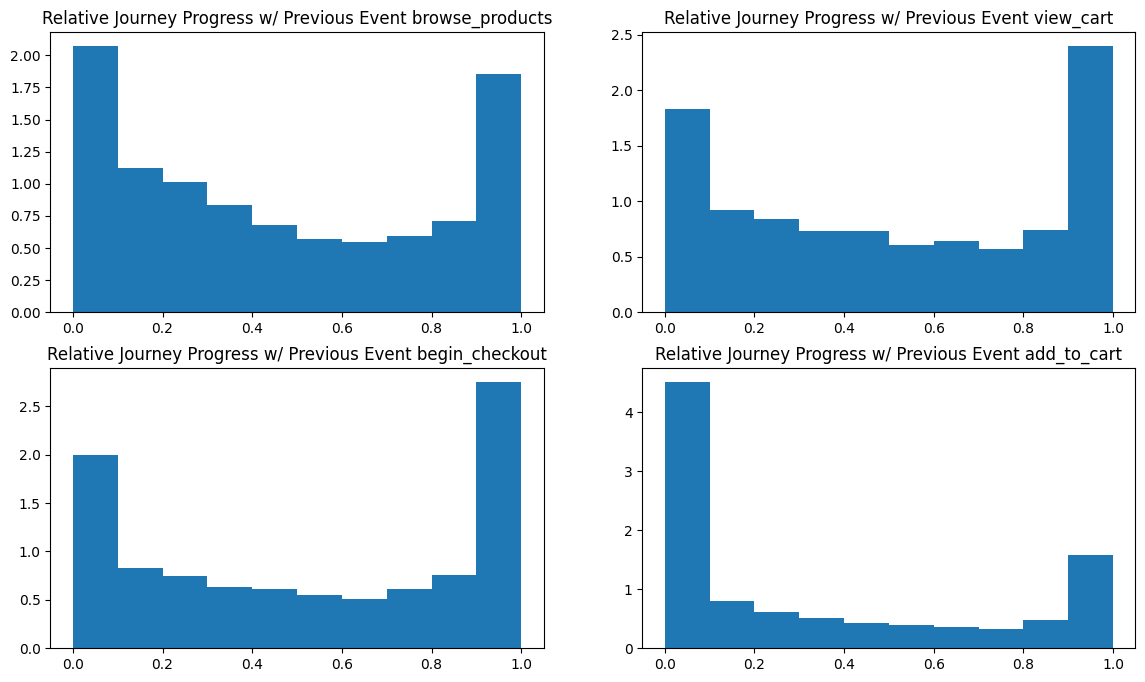

In [46]:
prev_events = ['browse_products', 'view_cart', 'begin_checkout', 'add_to_cart']

plt.figure(figsize=(14, 8))
for i, event in enumerate(prev_events):
    plt.subplot(2, 2, i+1)
    plt.hist(events_df_successful.loc[events_df_successful['previous_event'] == event, 'days_into_journey'] /
         events_df_successful.loc[events_df_successful['previous_event'] == event, 'days_in_journey'],
         density=True
    )
    plt.title(f'Relative Journey Progress w/ Previous Event {event}')

plt.show()

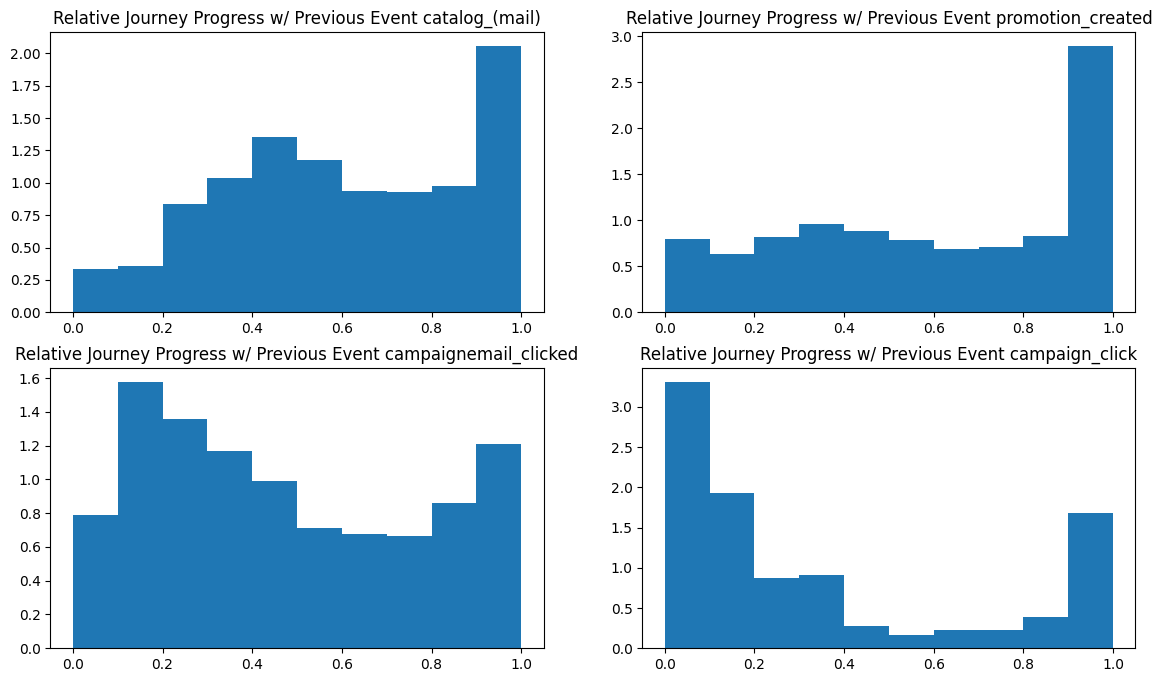

In [47]:
prev_events = ['catalog_(mail)', 'promotion_created', 'campaignemail_clicked', 'campaign_click']

plt.figure(figsize=(14, 8))
for i, event in enumerate(prev_events):
    plt.subplot(2, 2, i+1)
    plt.hist(events_df_successful.loc[events_df_successful['previous_event'] == event, 'days_into_journey'] /
         events_df_successful.loc[events_df_successful['previous_event'] == event, 'days_in_journey'],
         density=True
    )
    plt.title(f'Relative Journey Progress w/ Previous Event {event}')

plt.show()

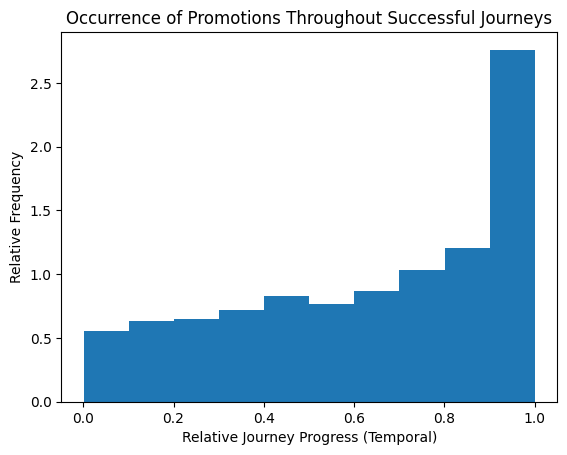

In [80]:
plt.hist(events_df_successful['relative_event_progress_through_journey'], density=True)
plt.xlabel('Relative Journey Progress (Temporal)')
plt.ylabel('Relative Frequency')
plt.title('Occurrence of Promotions Throughout Successful Journeys')
plt.show()

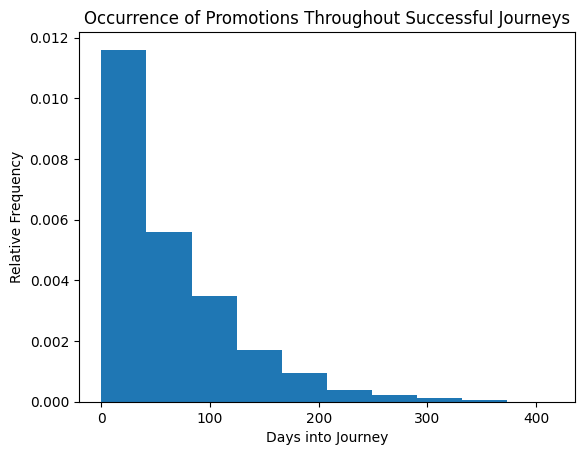

In [81]:
plt.hist(events_df_successful['days_into_journey'], density=True)
plt.xlabel('Days into Journey')
plt.ylabel('Relative Frequency')
plt.title('Occurrence of Promotions Throughout Successful Journeys')
plt.show()

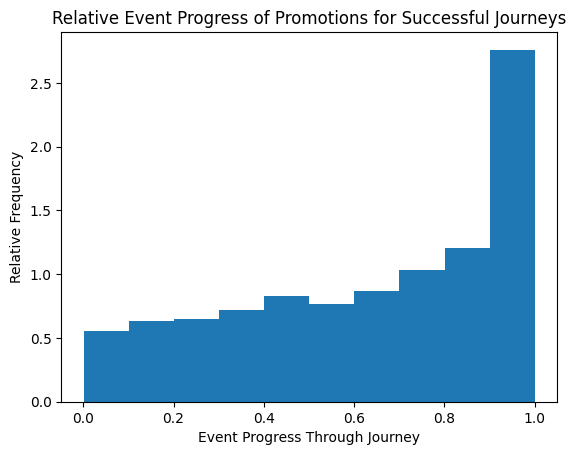

In [82]:
plt.hist(events_df_successful['relative_event_progress_through_journey'], density=True)
plt.xlabel('Event Progress Through Journey')
plt.ylabel('Relative Frequency')
plt.title('Relative Event Progress of Promotions for Successful Journeys')
plt.show()

In [83]:
successful_events_grouped = events_df_successful.groupby(['previous_event', 'next_event'])
display(successful_events_grouped['relative_event_progress_through_journey'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=10))
display(successful_events_grouped['time_delta_previous'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=12))
display(successful_events_grouped['time_delta_next'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=10))

count      mean    median  \
previous_event           next_event                                     
promotion_created        catalog_(mail)     15858  0.721186  0.800000   
browse_products          browse_products    14675  0.543963  0.551020   
catalog_(mail)           promotion_created   8495  0.753357  0.838710   
browse_products          promotion_created   7172  0.665161  0.724138   
                         catalog_(mail)      7131  0.657025  0.714286   
catalog_(mail)           catalog_(mail)      7042  0.736812  0.818182   
add_to_cart              browse_products     6795  0.378146  0.318182   
application_web_approved browse_products     6316  0.232747  0.153846   
add_to_cart              view_cart           5780  0.442466  0.423077   
promotion_created        None                5411  1.000000  1.000000   

                                                 var  
previous_event           next_event                   
promotion_created        catalog_(mail)     0.059737  
browse_products          browse_products    0.069823  
catalog_(mail)           promotion_created  0.052474  
browse_products          promotion_created  0.068638  
                         catalog_(mail)     0.068604  
catalog_(mail)           catalog_(mail)     0.054325  
add_to_cart              browse_products    0.065807  
application_web_approved browse_products    0.044613  
add_to_cart              view_cart          0.068629  
promotion_created        None               0.000000

count       mean     median  \
previous_event           next_event                                       
promotion_created        catalog_(mail)     15858  15.074510  10.558623   
browse_products          browse_products    14675   3.422442   0.023333   
catalog_(mail)           promotion_created   8495  22.854312  15.505023   
browse_products          promotion_created   7172  13.425422   6.701753   
                         catalog_(mail)      7131  12.289015  10.148056   
catalog_(mail)           catalog_(mail)      7042  18.443357  22.883877   
add_to_cart              browse_products     6795   0.031209   0.000012   
application_web_approved browse_products     6316   1.893422   0.000093   
add_to_cart              view_cart           5780   0.125033   0.000012   
promotion_created        None                5411  22.426215  18.382118   
view_cart                browse_products     4505   1.531972   0.021609   
browse_products          view_cart           4417   1.636677   0.022523   

                                                   var  
previous_event           next_event                     
promotion_created        catalog_(mail)     146.730227  
browse_products          browse_products    154.761463  
catalog_(mail)           promotion_created  462.986606  
browse_products          promotion_created  480.235078  
                         catalog_(mail)     181.166753  
catalog_(mail)           catalog_(mail)     389.369441  
add_to_cart              browse_products      7.638496  
application_web_approved browse_products    109.284388  
add_to_cart              view_cart            2.432563  
promotion_created        None               374.559383  
view_cart                browse_products    437.904657  
browse_products          view_cart          187.987834

count       mean     median  \
previous_event           next_event                                       
promotion_created        catalog_(mail)     15858   5.693405   2.136759   
browse_products          browse_products    14675   9.156105   1.770822   
catalog_(mail)           promotion_created   8495  20.490900  13.443646   
browse_products          promotion_created   7172  14.950771  10.558472   
                         catalog_(mail)      7131   6.609048   3.982176   
catalog_(mail)           catalog_(mail)      7042  17.691405   5.119120   
add_to_cart              browse_products     6795   1.372765   0.000486   
application_web_approved browse_products     6316   2.901719   0.005671   
add_to_cart              view_cart           5780   1.152661   0.000266   
view_cart                browse_products     4505  11.952502   2.573229   

                                                   var  
previous_event           next_event                     
promotion_created        catalog_(mail)      89.470699  
browse_products          browse_products    482.693163  
catalog_(mail)           promotion_created  193.824894  
browse_products          promotion_created  189.727763  
                         catalog_(mail)      80.014235  
catalog_(mail)           catalog_(mail)     281.936389  
add_to_cart              browse_products     62.343980  
application_web_approved browse_products    130.960419  
add_to_cart              view_cart           58.998494  
view_cart                browse_products    612.754983

In [ ]:
df.loc[(df['start_timestamp'] >= start_cutoff) & (df['start_timestamp'] < end_cutoff) & (df['outcome'] == 'unsuccessful'), 'event_names'].head().reset_index(drop=True)[0]

array(['pre-application_(3rd_party_affiliates)', 'campaign_click',
       'application_web_approved', 'promotion_created',
       'campaignemail_clicked', 'campaignemail_clicked',
       'campaignemail_clicked', 'campaignemail_clicked',
       'promotion_created', 'catalog_(mail)', 'promotion_created',
       'promotion_created', 'catalog_(mail)', 'promotion_created'],
      dtype=object)

In [142]:
df.loc[(df['start_timestamp'] >= start_cutoff) & (df['start_timestamp'] < end_cutoff) & (df['outcome'] == 'unsuccessful'), 'timestamps'].head().reset_index(drop=True)[0]

array(['2021-11-24T06:00:00.000000', '2021-11-24T06:00:00.000000',
       '2021-11-24T13:04:30.000000', '2021-11-24T13:04:38.000000',
       '2021-12-01T12:07:48.000000', '2021-12-01T23:38:09.000000',
       '2021-12-05T00:27:31.000000', '2021-12-06T12:12:28.000000',
       '2021-12-18T00:32:54.000000', '2021-12-22T00:00:00.000000',
       '2022-02-01T07:26:39.000000', '2022-02-11T20:49:06.000000',
       '2022-02-14T00:00:00.000000', '2022-04-12T12:11:10.000000'],
      dtype='datetime64[us]')

In [143]:
df.loc[(df['start_timestamp'] >= start_cutoff) & (df['start_timestamp'] < end_cutoff) & (df['outcome'] == 'unsuccessful'), 'event_names'].head().reset_index(drop=True)[1]

array(['campaign_click', 'application_web_view', 'application_web_view',
       'application_web_view', 'application_web_view',
       'application_web_view', 'application_web_view',
       'application_web_view', 'application_web_submit',
       'application_web_approved', 'browse_products', 'browse_products',
       'browse_products', 'add_to_cart', 'browse_products', 'view_cart',
       'browse_products', 'browse_products', 'browse_products',
       'browse_products', 'add_to_cart', 'browse_products',
       'browse_products', 'add_to_cart', 'browse_products',
       'browse_products', 'add_to_cart', 'view_cart', 'browse_products',
       'add_to_cart', 'browse_products', 'add_to_cart', 'browse_products',
       'view_cart', 'begin_checkout', 'view_cart', 'begin_checkout',
       'view_cart', 'browse_products', 'add_to_cart', 'view_cart',
       'begin_checkout', 'view_cart', 'begin_checkout', 'view_cart',
       'begin_checkout', 'begin_checkout', 'begin_checkout',
       'begin_ch

In [145]:
df.loc[(df['start_timestamp'] >= start_cutoff) & (df['start_timestamp'] < end_cutoff) & (df['outcome'] == 'unsuccessful')].head()

,id,events,event_names,timestamps,journey_length,outcome,start_timestamp,end_timestamp,current_datetime
1,550319820 1907517993,"[22, 2, 12, 1, 24, 24, 24, 24, 1, 21, 1, 1, 21...","[pre-application_(3rd_party_affiliates), campa...","[2021-11-24T06:00:00.000000, 2021-11-24T06:00:...",14,unsuccessful,2021-11-24 06:00:00+00:00,2022-09-12 12:07:39+00:00,2022-05-10 21:58:34+00:00
2,-931437166 -273076191,"[2, 19, 19, 19, 19, 19, 19, 19, 3, 12, 4, 4, 4...","[campaign_click, application_web_view, applica...","[2021-11-16T06:00:00.000000, 2021-11-16T18:27:...",58,unsuccessful,2021-11-16 06:00:00+00:00,2022-08-12 00:00:00+00:00,2022-08-06 21:35:26+00:00
3,-1633366293 2048161844,"[12, 4, 11, 5, 1]","[application_web_approved, browse_products, ad...","[2022-06-20T06:29:48.000000, 2022-06-20T06:32:...",5,unsuccessful,2022-06-20 06:29:48+00:00,2022-08-19 07:04:43+00:00,2022-08-06 21:35:26+00:00
4,14655434 -620023259,"[19, 19, 19, 19, 19, 19, 3, 19, 12, 4]","[application_web_view, application_web_view, a...","[2022-04-22T12:50:44.000000, 2022-04-22T12:50:...",10,unsuccessful,2022-04-22 12:50:44+00:00,2022-12-15 12:17:12+00:00,2022-08-06 21:35:26+00:00
7,402729126 821483213,"[2, 19, 19, 19, 19, 19, 19, 19, 19, 3, 12, 1, ...","[campaign_click, application_web_view, applica...","[2021-10-12T06:00:00.000000, 2021-10-12T21:47:...",29,unsuccessful,2021-10-12 06:00:00+00:00,2022-10-01 03:43:46+00:00,2022-06-20 13:14:14+00:00


In [144]:
df.loc[(df['start_timestamp'] >= start_cutoff) & (df['start_timestamp'] < end_cutoff) & (df['outcome'] == 'unsuccessful'), 'timestamps'].head().reset_index(drop=True)[1]

array(['2021-11-16T06:00:00.000000', '2021-11-16T18:27:16.000000',
       '2021-11-16T18:28:16.000000', '2021-11-16T18:28:18.000000',
       '2021-11-16T18:28:41.000000', '2021-11-16T18:28:44.000000',
       '2021-11-16T18:28:46.000000', '2021-11-16T18:28:55.000000',
       '2021-11-16T18:28:56.000000', '2021-11-16T18:29:05.000000',
       '2021-11-16T18:44:29.000000', '2021-11-16T18:51:50.000000',
       '2021-11-16T18:52:42.000000', '2021-11-16T18:53:14.000000',
       '2021-11-16T18:55:33.000000', '2021-11-16T18:55:48.000000',
       '2021-11-16T19:01:45.000000', '2021-11-16T19:17:04.000000',
       '2021-11-16T19:20:23.000000', '2021-11-16T19:21:09.000000',
       '2021-11-16T19:21:56.000000', '2021-11-16T19:22:14.000000',
       '2021-11-16T19:25:33.000000', '2021-11-16T19:26:00.000000',
       '2021-11-16T20:38:30.000000', '2021-11-16T20:40:32.000000',
       '2021-11-16T20:41:03.000000', '2021-11-16T20:41:22.000000',
       '2021-11-16T20:45:05.000000', '2021-11-16T20:45:42.0000

In [48]:
event_numbers = []
journey_times = []
journey_lengths = []
journey_time_proportions = []
previous_events = []
previous_time_diffs = []
next_events = []
next_time_diffs = []

for i, row in enumerate(df[(df['start_timestamp'] >= start_cutoff) & (df['start_timestamp'] < end_cutoff) & (df['outcome'] == 'unsuccessful')].itertuples(index=False)):
    promotion_indices = np.where(row.event_names == 'promotion_created')[0]

    if len(promotion_indices) > 0:
        event_numbers.extend(promotion_indices + 1)
        journey_times.extend((row.timestamps[promotion_indices] - row.timestamps[0]) / np.timedelta64(1, 'D'))
        journey_lengths.extend(len(promotion_indices) * [(row.timestamps[-1] - row.timestamps[0]) / np.timedelta64(1, 'D')])
        journey_time_proportions.extend((promotion_indices + 1) / len(row.event_names))
        previous_indices = promotion_indices - 1
        previous_events.extend(row.event_names[previous_indices])
        previous_time_diffs.extend((row.timestamps[promotion_indices] - row.timestamps[previous_indices]) / np.timedelta64(1, 'D'))

        next_indices = promotion_indices + 1
        if next_indices[-1] < len(row.event_names):
            next_events.extend(row.event_names[next_indices])
        else:
            next_events.extend(np.append(row.event_names[next_indices[:len(next_indices) - 1]], 'None'))

        if next_indices[-1] < len(row.event_names):
            next_time_diffs.extend((row.timestamps[next_indices] - row.timestamps[promotion_indices]) / np.timedelta64(1, 'D'))
        else:
            next_time_diffs.extend(np.append((row.timestamps[next_indices[:len(next_indices) - 1]] - row.timestamps[promotion_indices[:len(promotion_indices) - 1]]) / np.timedelta64(1, 'D'), np.nan))


events_df_unsuccessful = pd.DataFrame({
    'event_number': event_numbers,
    'days_into_journey': journey_times,
    'days_in_journey': journey_lengths,
    'relative_event_progress_through_journey': journey_time_proportions,
    'previous_event': previous_events,
    'time_delta_previous': previous_time_diffs,
    'next_event': next_events,
    'time_delta_next': next_time_diffs
})

In [49]:
events_df_unsuccessful.groupby('previous_event')['time_delta_previous'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=12)

,count,mean,median,var
previous_event,,,,
catalog_(mail),799892,23.907758,22.890995,593.218332
promotion_created,792018,15.484436,10.558912,840.881822
browse_products,471144,10.397028,4.698148,764.913981
application_web_approved,256198,12.149128,0.000185,416.669886
campaignemail_clicked,235786,15.949351,12.371939,555.794484
begin_checkout,163225,8.399892,0.022593,461.505650
view_cart,162010,8.791750,0.305069,586.310188
add_to_cart,156540,1.020016,0.000012,57.565720
application_web_view,49180,13.950844,12.692326,1147.751628


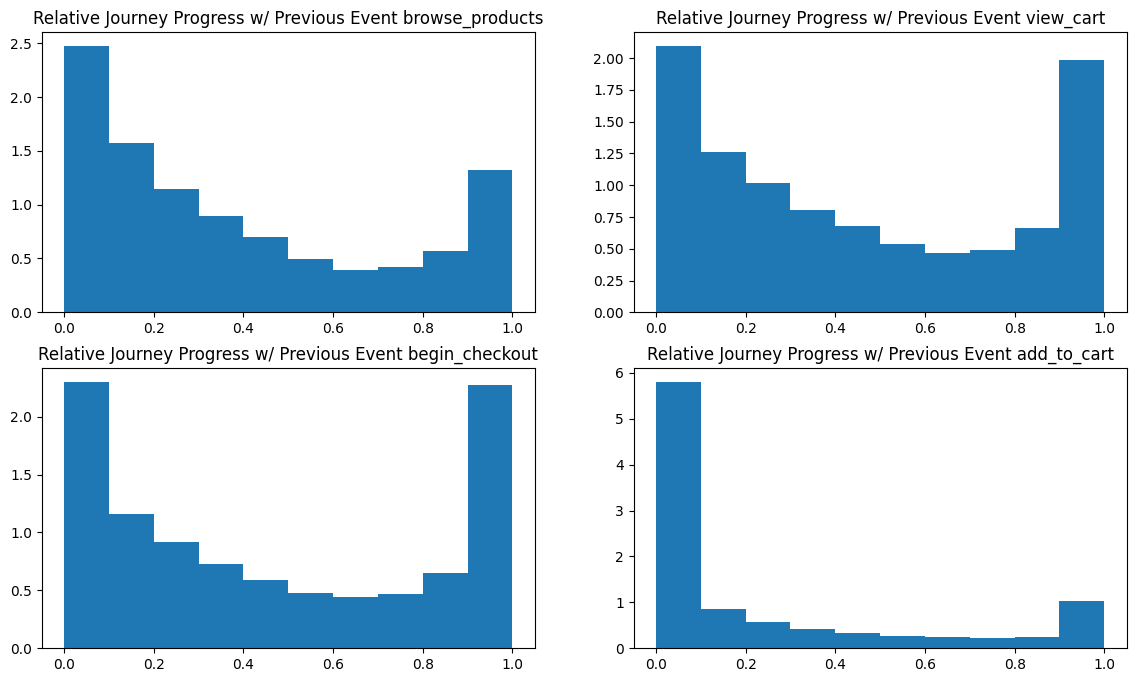

In [50]:
prev_events = ['browse_products', 'view_cart', 'begin_checkout', 'add_to_cart']

plt.figure(figsize=(14, 8))
for i, event in enumerate(prev_events):
    plt.subplot(2, 2, i+1)
    plt.hist(events_df_unsuccessful.loc[events_df_unsuccessful['previous_event'] == event, 'days_into_journey'] /
         events_df_unsuccessful.loc[events_df_unsuccessful['previous_event'] == event, 'days_in_journey'],
         density=True
    )
    plt.title(f'Relative Journey Progress w/ Previous Event {event}')

plt.show()

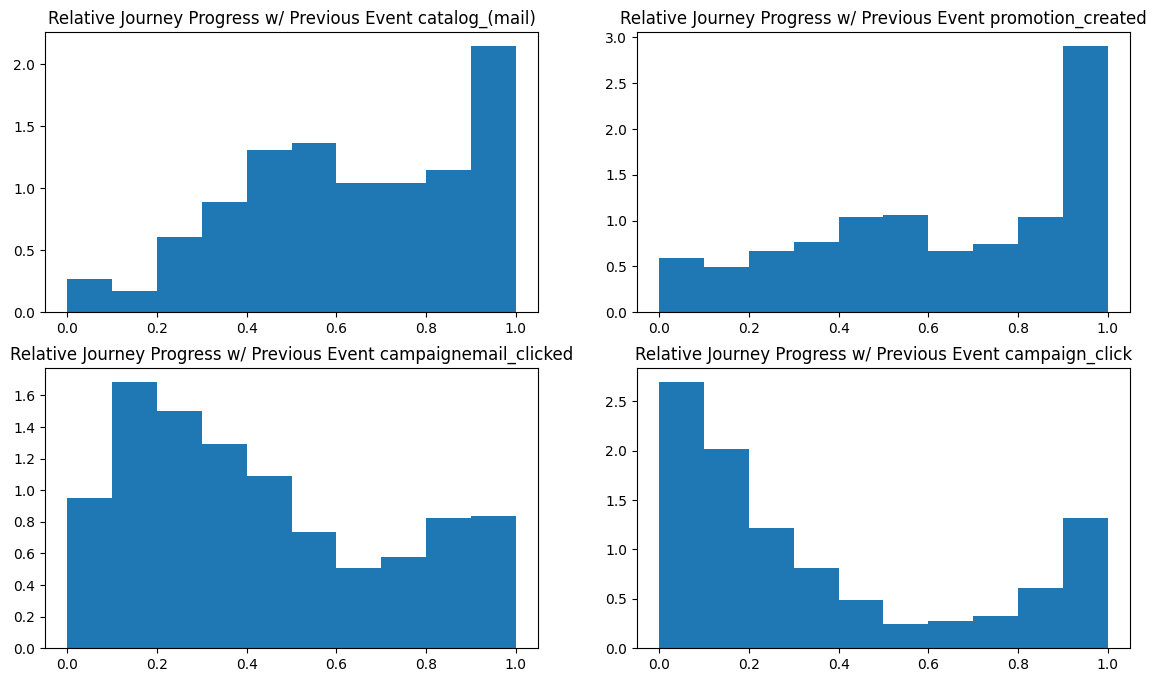

In [51]:
prev_events = ['catalog_(mail)', 'promotion_created', 'campaignemail_clicked', 'campaign_click']

plt.figure(figsize=(14, 8))
for i, event in enumerate(prev_events):
    plt.subplot(2, 2, i+1)
    plt.hist(events_df_unsuccessful.loc[events_df_unsuccessful['previous_event'] == event, 'days_into_journey'] /
         events_df_unsuccessful.loc[events_df_unsuccessful['previous_event'] == event, 'days_in_journey'],
         density=True
    )
    plt.title(f'Relative Journey Progress w/ Previous Event {event}')

plt.show()

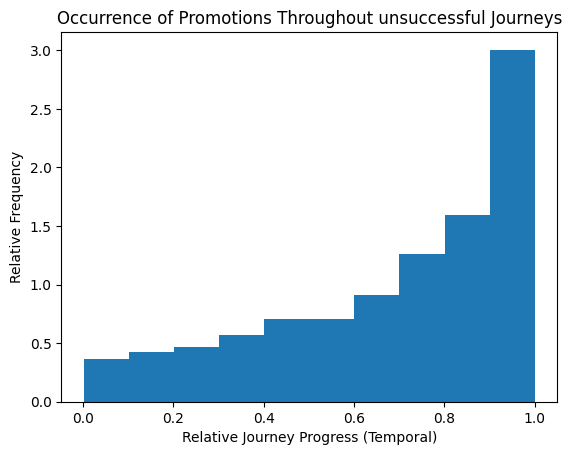

In [85]:
plt.hist(events_df_unsuccessful['relative_event_progress_through_journey'], density=True)
plt.xlabel('Relative Journey Progress (Temporal)')
plt.ylabel('Relative Frequency')
plt.title('Occurrence of Promotions Throughout unsuccessful Journeys')
plt.show()

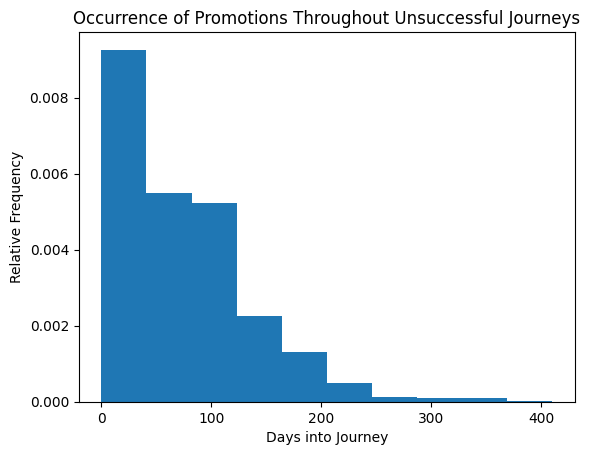

In [86]:
plt.hist(events_df_unsuccessful['days_into_journey'], density=True)
plt.xlabel('Days into Journey')
plt.ylabel('Relative Frequency')
plt.title('Occurrence of Promotions Throughout Unsuccessful Journeys')
plt.show()

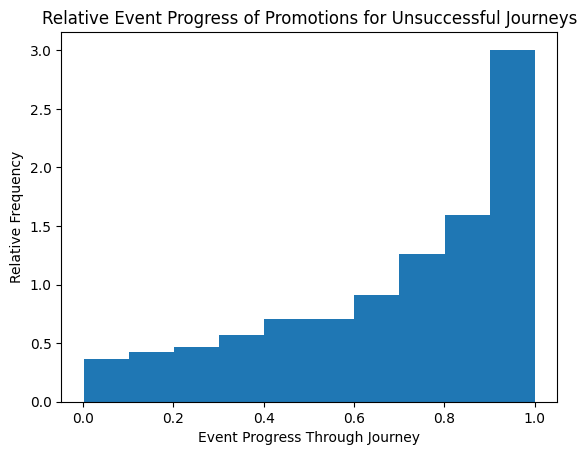

In [87]:
plt.hist(events_df_unsuccessful['relative_event_progress_through_journey'], density=True)
plt.xlabel('Event Progress Through Journey')
plt.ylabel('Relative Frequency')
plt.title('Relative Event Progress of Promotions for Unsuccessful Journeys')
plt.show()

In [88]:
unsuccessful_events_grouped = events_df_unsuccessful.groupby(['previous_event', 'next_event'])
display(unsuccessful_events_grouped['relative_event_progress_through_journey'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=10))
display(unsuccessful_events_grouped['time_delta_previous'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=10))
display(unsuccessful_events_grouped['time_delta_next'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=10))

count      mean    median  \
previous_event           next_event                                      
promotion_created        catalog_(mail)     494127  0.751445  0.814570   
catalog_(mail)           promotion_created  320868  0.781120  0.833333   
                         catalog_(mail)     278687  0.781091  0.846154   
browse_products          catalog_(mail)     137498  0.658406  0.700000   
promotion_created        None               128446  1.000000  1.000000   
catalog_(mail)           None               121092  1.000000  1.000000   
browse_products          browse_products    114682  0.543249  0.550000   
campaignemail_clicked    catalog_(mail)     111676  0.664062  0.702703   
browse_products          promotion_created  110910  0.698316  0.750000   
application_web_approved browse_products     96143  0.229248  0.160494   

                                                 var  
previous_event           next_event                   
promotion_created        catalog_(mail)     0.042568  
catalog_(mail)           promotion_created  0.032389  
                         catalog_(mail)     0.038130  
browse_products          catalog_(mail)     0.054562  
promotion_created        None               0.000000  
catalog_(mail)           None               0.000000  
browse_products          browse_products    0.069576  
campaignemail_clicked    catalog_(mail)     0.051439  
browse_products          promotion_created  0.051646  
application_web_approved browse_products    0.040085

count       mean     median  \
previous_event           next_event                                        
promotion_created        catalog_(mail)     494127  13.234636  10.558171   
catalog_(mail)           promotion_created  320868  32.756581  41.302720   
                         catalog_(mail)     278687  20.833003  22.890995   
browse_products          catalog_(mail)     137498  15.393322  14.944896   
promotion_created        None               128446  25.878109  20.794213   
catalog_(mail)           None               121092  18.752523  15.503773   
browse_products          browse_products    114682   3.476546   0.023299   
campaignemail_clicked    catalog_(mail)     111676  12.255636  10.283738   
browse_products          promotion_created  110910  19.986767  12.997431   
application_web_approved browse_products     96143   1.328056   0.000093   

                                                   var  
previous_event           next_event                     
promotion_created        catalog_(mail)     302.297080  
catalog_(mail)           promotion_created  454.596125  
                         catalog_(mail)     464.707146  
browse_products          catalog_(mail)     343.504242  
promotion_created        None               374.762975  
catalog_(mail)           None               199.633235  
browse_products          browse_products    388.988473  
campaignemail_clicked    catalog_(mail)     259.250387  
browse_products          promotion_created  748.207695  
application_web_approved browse_products     95.110412

count       mean     median  \
previous_event           next_event                                        
promotion_created        catalog_(mail)     494127   5.382755   2.133484   
catalog_(mail)           promotion_created  320868  19.451129  10.560532   
                         catalog_(mail)     278687  15.800815   5.109583   
browse_products          catalog_(mail)     137498   5.699815   3.977569   
                         browse_products    114682  10.033403   1.563854   
campaignemail_clicked    catalog_(mail)     111676   5.754789   3.977558   
browse_products          promotion_created  110910  15.721226  10.558495   
application_web_approved browse_products     96143   3.024188   0.004537   
promotion_created        promotion_created   88260  26.162188  20.804363   
campaignemail_clicked    promotion_created   77003  13.670928  10.558044   

                                                   var  
previous_event           next_event                     
promotion_created        catalog_(mail)      94.756199  
catalog_(mail)           promotion_created  192.571550  
                         catalog_(mail)     305.467867  
browse_products          catalog_(mail)      67.437623  
                         browse_products    657.027659  
campaignemail_clicked    catalog_(mail)      79.892297  
browse_products          promotion_created  218.850607  
application_web_approved browse_products    282.810595  
promotion_created        promotion_created  250.328287  
campaignemail_clicked    promotion_created   84.337556

In [89]:
successful_events_grouped['time_delta_next'].agg(["count", "median"]).sort_values(by="median").head(n=10)

,,count,median
previous_event,next_event,,
account_downpaymentcleared,promotion_created,19,0.000012
place_downpayment,promotion_created,9,0.000012
application_web_submit,promotion_created,165,0.000012
promotion_created,add_to_cart,26,0.000023
browse_products,add_to_cart,301,0.000035
application_web_view,application_web_submit,1,0.000046
add_to_cart,add_to_cart,121,0.000185
campaign_click,view_cart,63,0.000266
add_to_cart,view_cart,5780,0.000266


In [90]:
unsuccessful_events_grouped['time_delta_next'].agg(["count", "median"]).sort_values(by="median").head(n=10)

count    median
previous_event             next_event                             
application_phone_declined promotion_created           1  0.000012
application_web_view       add_to_cart                 8  0.000012
browse_products            add_to_cart              3583  0.000012
application_web_view       application_web_submit     13  0.000139
application_web_submit     application_web_submit     27  0.000208
add_to_cart                view_cart               65398  0.000220
                           add_to_cart               992  0.000336
application_web_approved   begin_checkout           2834  0.000370
add_to_cart                browse_products         69746  0.000405
catalog_(email)_(experian) application_web_view        2  0.000718

In [91]:
events_df_successful[['previous_event', 'next_event']].value_counts(normalize=True)[:10]

previous_event            next_event       
promotion_created         catalog_(mail)       0.090652
browse_products           browse_products      0.083890
catalog_(mail)            promotion_created    0.048562
browse_products           promotion_created    0.040999
                          catalog_(mail)       0.040764
catalog_(mail)            catalog_(mail)       0.040256
add_to_cart               browse_products      0.038844
application_web_approved  browse_products      0.036105
add_to_cart               view_cart            0.033041
promotion_created         None                 0.030932
Name: proportion, dtype: float64

In [92]:
events_df_unsuccessful[['previous_event', 'next_event']].value_counts(normalize=True)[:10]

previous_event            next_event       
promotion_created         catalog_(mail)       0.157218
catalog_(mail)            promotion_created    0.102092
                          catalog_(mail)       0.088671
browse_products           catalog_(mail)       0.043748
promotion_created         None                 0.040868
catalog_(mail)            None                 0.038528
browse_products           browse_products      0.036489
campaignemail_clicked     catalog_(mail)       0.035532
browse_products           promotion_created    0.035289
application_web_approved  browse_products      0.030590
Name: proportion, dtype: float64

### Analysis after July 2022

In [93]:
start_cutoff = pd.Timestamp('2022-07-01', tz='UTC')

In [55]:
event_numbers = []
journey_times = []
journey_lengths = []
journey_time_proportions = []
previous_events = []
previous_time_diffs = []
next_events = []
next_time_diffs = []

for i, row in enumerate(df[(df['start_timestamp'] >= start_cutoff) & (df['outcome'] == 'successful')].itertuples(index=False)):
    promotion_indices = np.where(row.event_names == 'promotion_created')[0]

    if len(promotion_indices) > 0:
        event_numbers.extend(promotion_indices + 1)
        journey_times.extend((row.timestamps[promotion_indices] - row.timestamps[0]) / np.timedelta64(1, 'D'))
        journey_lengths.extend(len(promotion_indices) * [(row.timestamps[-1] - row.timestamps[0]) / np.timedelta64(1, 'D')])
        journey_time_proportions.extend((promotion_indices + 1) / len(row.event_names))
        previous_indices = promotion_indices - 1
        previous_events.extend(row.event_names[previous_indices])
        previous_time_diffs.extend((row.timestamps[promotion_indices] - row.timestamps[previous_indices]) / np.timedelta64(1, 'D'))

        next_indices = promotion_indices + 1
        if next_indices[-1] < len(row.event_names):
            next_events.extend(row.event_names[next_indices])
        else:
            next_events.extend(np.append(row.event_names[next_indices[:len(next_indices) - 1]], 'None'))

        if next_indices[-1] < len(row.event_names):
            next_time_diffs.extend((row.timestamps[next_indices] - row.timestamps[promotion_indices]) / np.timedelta64(1, 'D'))
        else:
            next_time_diffs.extend(np.append((row.timestamps[next_indices[:len(next_indices) - 1]] - row.timestamps[promotion_indices[:len(promotion_indices) - 1]]) / np.timedelta64(1, 'D'), np.nan))


events_df_successful = pd.DataFrame({
    'event_number': event_numbers,
    'days_into_journey': journey_times,
    'days_in_journey': journey_lengths,
    'relative_event_progress_through_journey': journey_time_proportions,
    'previous_event': previous_events,
    'time_delta_previous': previous_time_diffs,
    'next_event': next_events,
    'time_delta_next': next_time_diffs
})

In [56]:
events_df_successful.groupby('previous_event')['time_delta_previous'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=12)

,count,mean,median,var
previous_event,,,,
browse_products,58666,4.043219,0.023553,296.493895
promotion_created,35383,13.478358,10.558646,629.168230
begin_checkout,30425,1.878697,0.021435,207.078111
view_cart,29078,1.799387,0.021586,300.448285
catalog_(mail),24804,17.558067,15.504850,457.846357
add_to_cart,19530,0.317966,0.000023,15.515938
application_web_approved,12267,6.738320,0.000116,251.086850
campaignemail_clicked,10932,12.613675,9.649774,462.737601
application_web_view,3931,5.625588,0.021181,331.976573


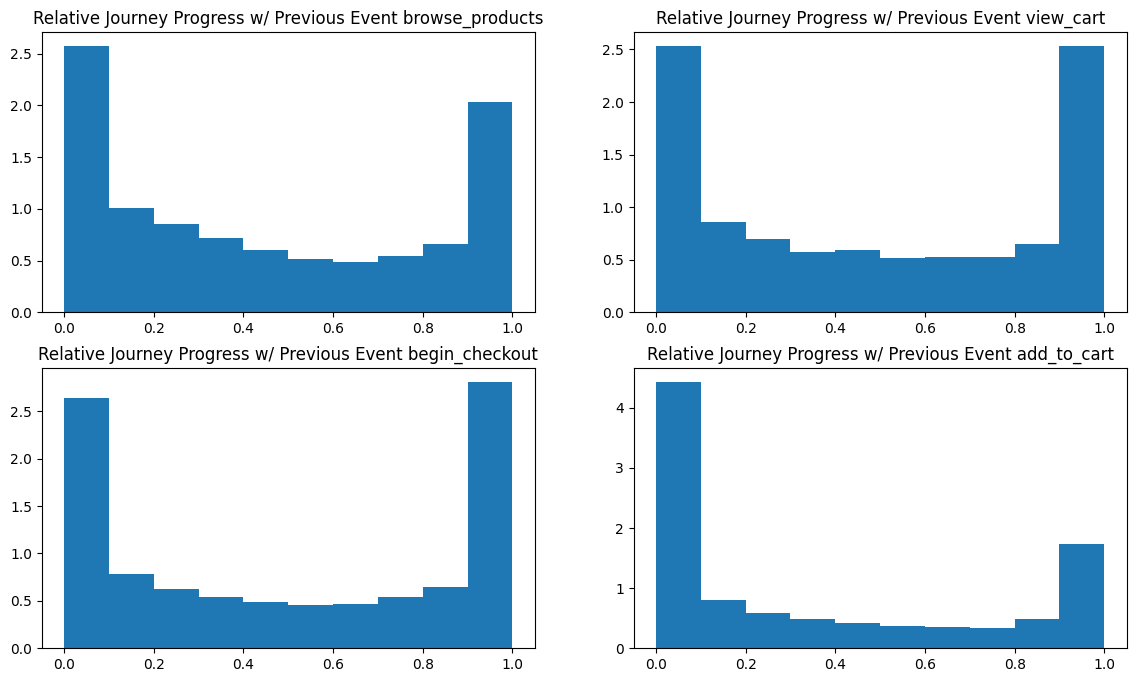

In [57]:
prev_events = ['browse_products', 'view_cart', 'begin_checkout', 'add_to_cart']

plt.figure(figsize=(14, 8))
for i, event in enumerate(prev_events):
    plt.subplot(2, 2, i+1)
    plt.hist(events_df_successful.loc[events_df_successful['previous_event'] == event, 'days_into_journey'] /
         events_df_successful.loc[events_df_successful['previous_event'] == event, 'days_in_journey'],
         density=True
    )
    plt.title(f'Relative Journey Progress w/ Previous Event {event}')

plt.show()

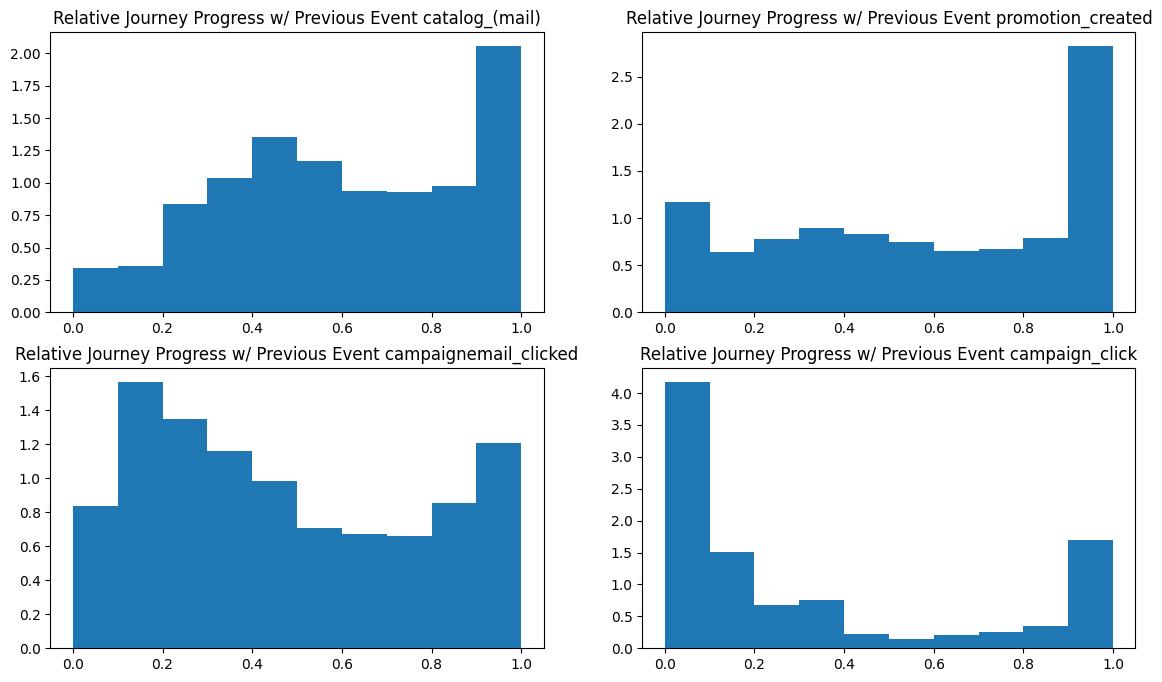

In [58]:
prev_events = ['catalog_(mail)', 'promotion_created', 'campaignemail_clicked', 'campaign_click']

plt.figure(figsize=(14, 8))
for i, event in enumerate(prev_events):
    plt.subplot(2, 2, i+1)
    plt.hist(events_df_successful.loc[events_df_successful['previous_event'] == event, 'days_into_journey'] /
         events_df_successful.loc[events_df_successful['previous_event'] == event, 'days_in_journey'],
         density=True
    )
    plt.title(f'Relative Journey Progress w/ Previous Event {event}')

plt.show()

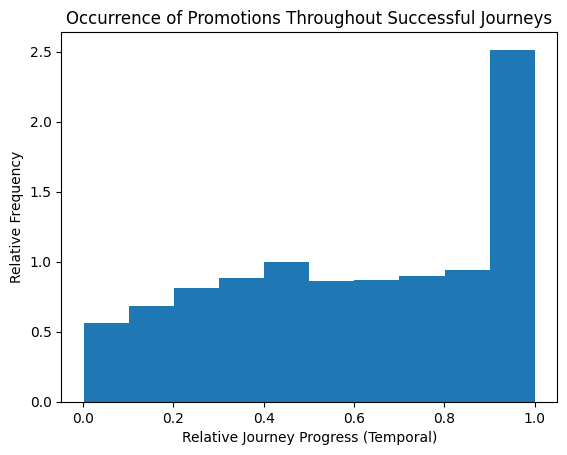

In [95]:
plt.hist(events_df_successful['relative_event_progress_through_journey'], density=True)
plt.xlabel('Relative Journey Progress (Temporal)')
plt.ylabel('Relative Frequency')
plt.title('Occurrence of Promotions Throughout Successful Journeys')
plt.show()

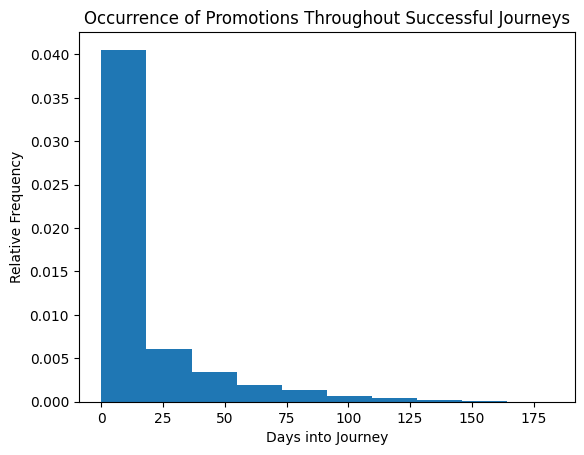

In [96]:
plt.hist(events_df_successful['days_into_journey'], density=True)
plt.xlabel('Days into Journey')
plt.ylabel('Relative Frequency')
plt.title('Occurrence of Promotions Throughout Successful Journeys')
plt.show()

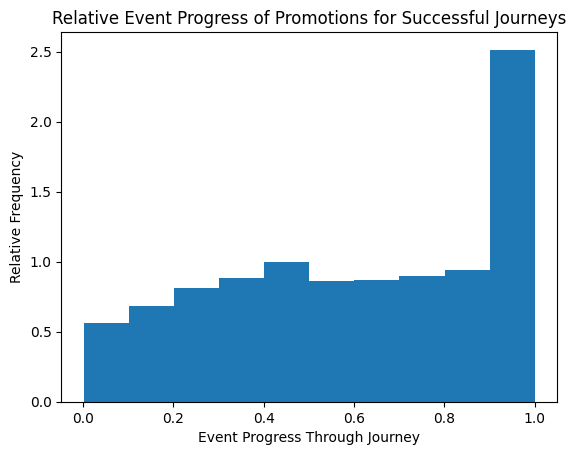

In [97]:
plt.hist(events_df_successful['relative_event_progress_through_journey'], density=True)
plt.xlabel('Event Progress Through Journey')
plt.ylabel('Relative Frequency')
plt.title('Relative Event Progress of Promotions for Successful Journeys')
plt.show()

In [98]:
successful_events_grouped = events_df_successful.groupby(['previous_event', 'next_event'])
display(successful_events_grouped['relative_event_progress_through_journey'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=10))
display(successful_events_grouped['time_delta_previous'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=12))
display(successful_events_grouped['time_delta_next'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=10))

count      mean    median       var
previous_event  next_event                                          
browse_products browse_products   8095  0.504760  0.489362  0.069954
view_cart       view_cart         3985  0.603087  0.626943  0.064520
browse_products view_cart         3565  0.555619  0.551724  0.062181
view_cart       browse_products   3524  0.554110  0.560303  0.071332
begin_checkout  view_cart         3072  0.647553  0.681818  0.056235
                browse_products   2774  0.575916  0.589500  0.064352
browse_products None              2190  1.000000  1.000000  0.000000
begin_checkout  None              2164  1.000000  1.000000  0.000000
add_to_cart     browse_products   1961  0.438359  0.428571  0.065848
view_cart       None              1799  1.000000  1.000000  0.000000

count      mean    median        var
previous_event  next_event                                           
browse_products browse_products   8095 -0.150004  0.021667  30.417078
view_cart       view_cart         3985  0.096849  0.021389   4.903353
browse_products view_cart         3565  0.166001  0.021806   5.470798
view_cart       browse_products   3524 -0.117682  0.021412  36.022037
begin_checkout  view_cart         3072  0.049678  0.021319   1.929940
                browse_products   2774 -0.274594  0.021285  33.329966
browse_products None              2190  0.220234  0.021910   4.007177
begin_checkout  None              2164  0.091405  0.021308   1.326621
add_to_cart     browse_products   1961  0.006356  0.021100   9.405579
view_cart       None              1799  0.074851  0.021424   0.456148
browse_products campaign_click    1684 -0.480693  0.021956  30.835352
begin_checkout  begin_checkout    1622  0.021837  0.021366   0.000165

count      mean    median         var
previous_event  next_event                                            
browse_products browse_products   8095  3.323885  0.352095   92.065611
view_cart       view_cart         3985  3.411363  0.540058   69.759142
browse_products view_cart         3565  4.035167  0.834248   63.515265
view_cart       browse_products   3524  5.107827  0.676667  153.085630
begin_checkout  view_cart         3072  4.932186  0.997928   97.305260
                browse_products   2774  7.712743  1.921447  237.603171
add_to_cart     browse_products   1961  2.679292  0.042917   70.551741
browse_products campaign_click    1684  0.213281  0.205579    0.086118
begin_checkout  begin_checkout    1622  0.846042  0.143848    5.772045
add_to_cart     view_cart         1539  2.637786  0.078368   46.683163

In [59]:
event_numbers = []
journey_times = []
journey_lengths = []
journey_time_proportions = []
previous_events = []
previous_time_diffs = []
next_events = []
next_time_diffs = []

for i, row in enumerate(df[(df['start_timestamp'] >= start_cutoff) & (df['outcome'] == 'unsuccessful')].itertuples(index=False)):
    promotion_indices = np.where(row.event_names == 'promotion_created')[0]

    if len(promotion_indices) > 0:
        event_numbers.extend(promotion_indices + 1)
        journey_times.extend((row.timestamps[promotion_indices] - row.timestamps[0]) / np.timedelta64(1, 'D'))
        journey_lengths.extend(len(promotion_indices) * [(row.timestamps[-1] - row.timestamps[0]) / np.timedelta64(1, 'D')])
        journey_time_proportions.extend((promotion_indices + 1) / len(row.event_names))
        previous_indices = promotion_indices - 1
        previous_events.extend(row.event_names[previous_indices])
        previous_time_diffs.extend((row.timestamps[promotion_indices] - row.timestamps[previous_indices]) / np.timedelta64(1, 'D'))

        next_indices = promotion_indices + 1
        if next_indices[-1] < len(row.event_names):
            next_events.extend(row.event_names[next_indices])
        else:
            next_events.extend(np.append(row.event_names[next_indices[:len(next_indices) - 1]], 'None'))

        if next_indices[-1] < len(row.event_names):
            next_time_diffs.extend((row.timestamps[next_indices] - row.timestamps[promotion_indices]) / np.timedelta64(1, 'D'))
        else:
            next_time_diffs.extend(np.append((row.timestamps[next_indices[:len(next_indices) - 1]] - row.timestamps[promotion_indices[:len(promotion_indices) - 1]]) / np.timedelta64(1, 'D'), np.nan))


events_df_unsuccessful = pd.DataFrame({
    'event_number': event_numbers,
    'days_into_journey': journey_times,
    'days_in_journey': journey_lengths,
    'relative_event_progress_through_journey': journey_time_proportions,
    'previous_event': previous_events,
    'time_delta_previous': previous_time_diffs,
    'next_event': next_events,
    'time_delta_next': next_time_diffs
})

In [60]:
events_df_unsuccessful.groupby('previous_event')['time_delta_previous'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=12)

,count,mean,median,var
previous_event,,,,
promotion_created,810157,15.113741,10.558866,830.536417
catalog_(mail),800377,23.899508,22.890995,593.080120
browse_products,551671,8.800255,1.272627,675.099380
application_web_approved,264006,11.796669,0.000220,410.217720
begin_checkout,244187,5.579555,0.021701,328.065357
campaignemail_clicked,236102,15.921159,12.358275,557.007753
view_cart,226181,6.240435,0.022361,440.845701
add_to_cart,180876,0.883430,0.000012,50.002358
application_web_view,57956,11.786460,8.740226,1006.082921


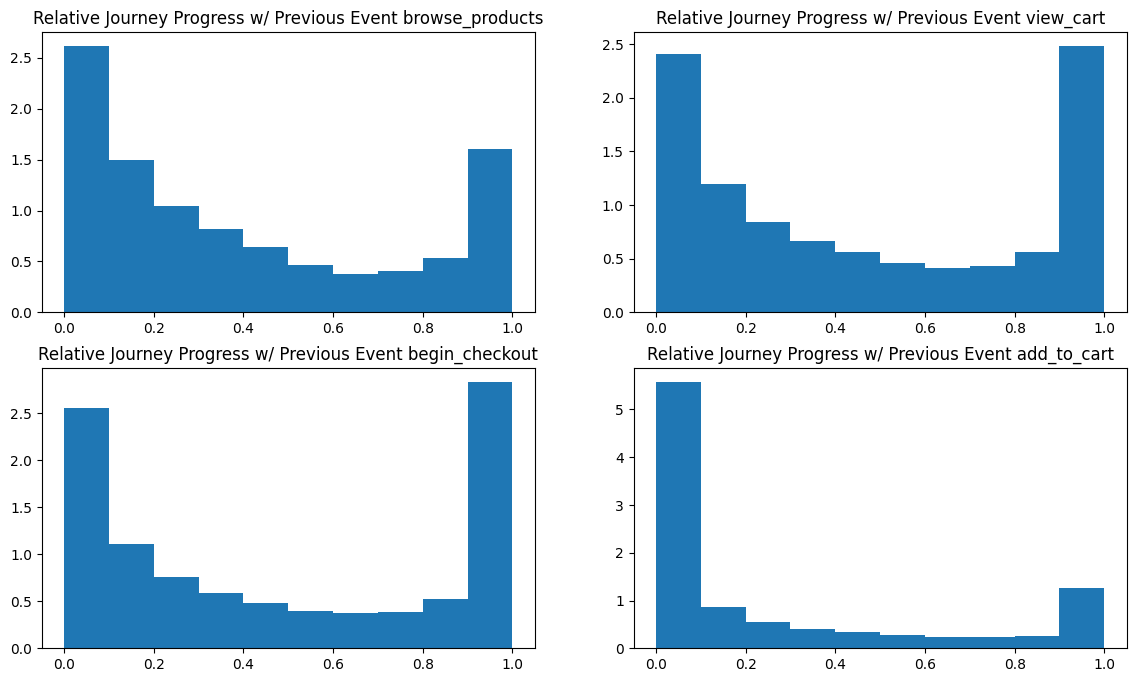

In [61]:
prev_events = ['browse_products', 'view_cart', 'begin_checkout', 'add_to_cart']

plt.figure(figsize=(14, 8))
for i, event in enumerate(prev_events):
    plt.subplot(2, 2, i+1)
    plt.hist(events_df_unsuccessful.loc[events_df_unsuccessful['previous_event'] == event, 'days_into_journey'] /
         events_df_unsuccessful.loc[events_df_unsuccessful['previous_event'] == event, 'days_in_journey'],
         density=True
    )
    plt.title(f'Relative Journey Progress w/ Previous Event {event}')

plt.show()

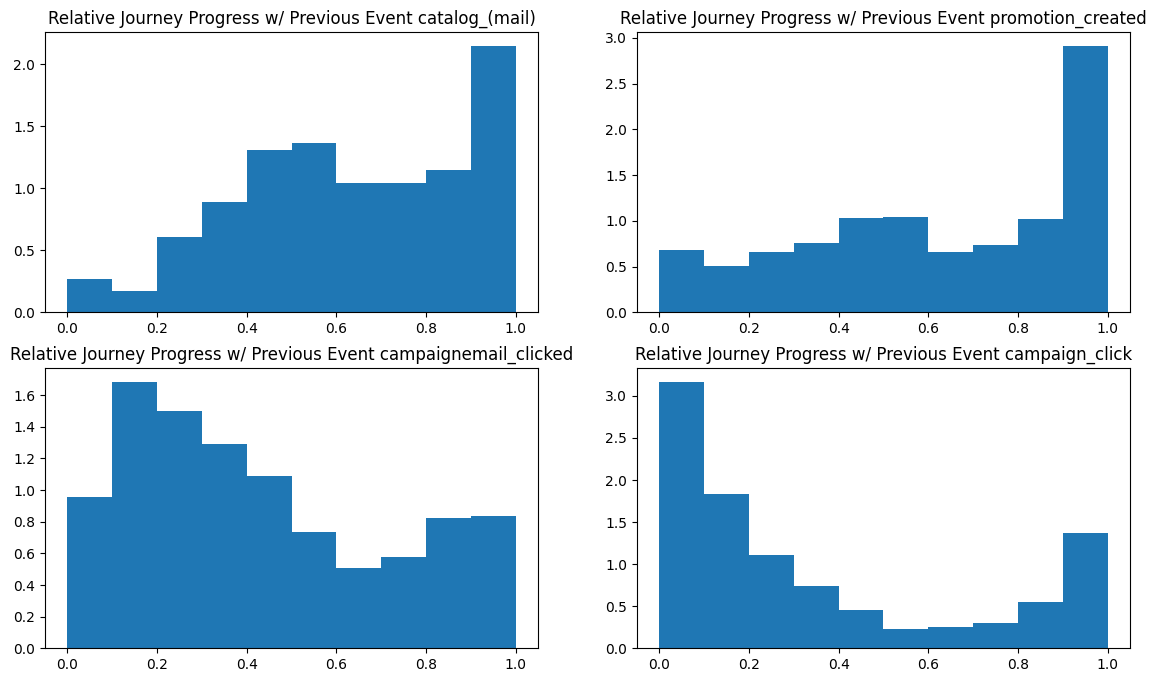

In [62]:
prev_events = ['catalog_(mail)', 'promotion_created', 'campaignemail_clicked', 'campaign_click']

plt.figure(figsize=(14, 8))
for i, event in enumerate(prev_events):
    plt.subplot(2, 2, i+1)
    plt.hist(events_df_unsuccessful.loc[events_df_unsuccessful['previous_event'] == event, 'days_into_journey'] /
         events_df_unsuccessful.loc[events_df_unsuccessful['previous_event'] == event, 'days_in_journey'],
         density=True
    )
    plt.title(f'Relative Journey Progress w/ Previous Event {event}')

plt.show()

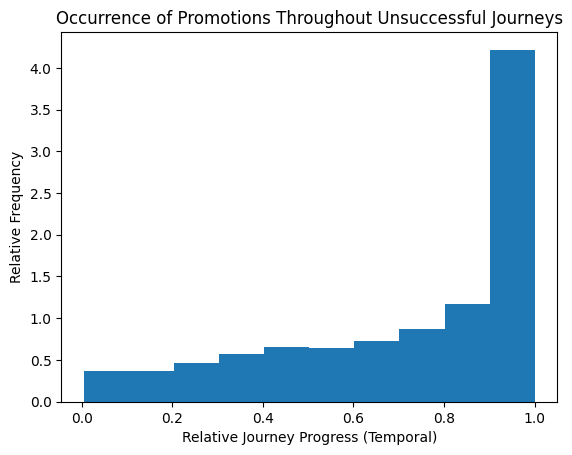

In [100]:
plt.hist(events_df_unsuccessful['relative_event_progress_through_journey'], density=True)
plt.xlabel('Relative Journey Progress (Temporal)')
plt.ylabel('Relative Frequency')
plt.title('Occurrence of Promotions Throughout Unsuccessful Journeys')
plt.show()

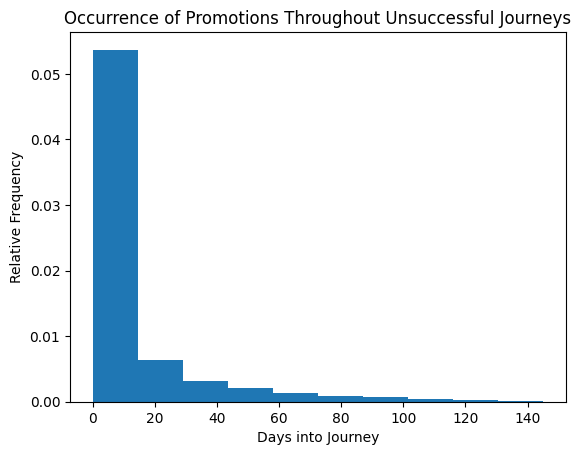

In [101]:
plt.hist(events_df_unsuccessful['days_into_journey'], density=True)
plt.xlabel('Days into Journey')
plt.ylabel('Relative Frequency')
plt.title('Occurrence of Promotions Throughout Unsuccessful Journeys')
plt.show()

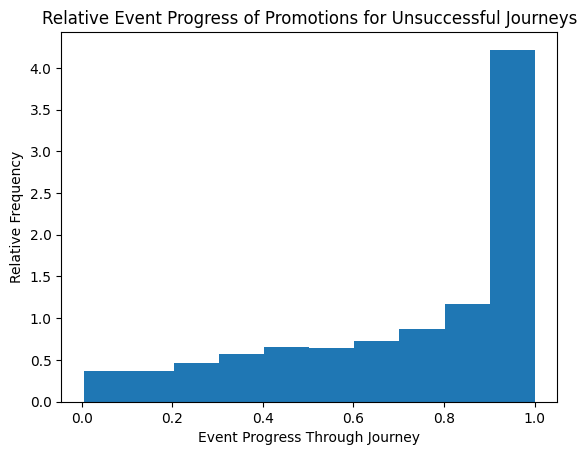

In [102]:
plt.hist(events_df_unsuccessful['relative_event_progress_through_journey'], density=True)
plt.xlabel('Event Progress Through Journey')
plt.ylabel('Relative Frequency')
plt.title('Relative Event Progress of Promotions for Unsuccessful Journeys')
plt.show()

In [103]:
unsuccessful_events_grouped = events_df_unsuccessful.groupby(['previous_event', 'next_event'])
display(unsuccessful_events_grouped['relative_event_progress_through_journey'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=10))
display(unsuccessful_events_grouped['time_delta_previous'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=10))
display(unsuccessful_events_grouped['time_delta_next'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=10))

count      mean    median       var
previous_event  next_event                                          
browse_products browse_products  29336  0.589740  0.613636  0.066507
begin_checkout  None             24484  1.000000  1.000000  0.000000
browse_products None             18607  1.000000  1.000000  0.000000
view_cart       None             17998  1.000000  1.000000  0.000000
                browse_products  14386  0.621340  0.666667  0.062980
                view_cart        13618  0.683482  0.739130  0.058129
begin_checkout  campaign_click   13150  0.791276  0.875000  0.044632
                view_cart        12540  0.679036  0.729730  0.053925
                browse_products  11544  0.671278  0.727273  0.058906
browse_products campaign_click   11281  0.740641  0.857143  0.059016

count      mean    median        var
previous_event  next_event                                           
browse_products browse_products  29336 -0.413094  0.021551  52.218446
begin_checkout  None             24484  0.074066  0.021389   2.165087
browse_products None             18607  0.200810  0.021840   4.942475
view_cart       None             17998  0.045229  0.021435   0.367930
                browse_products  14386 -0.405401  0.021470  35.786916
                view_cart        13618  0.050017  0.021354   0.755291
begin_checkout  campaign_click   13150  0.007615  0.021458   0.155716
                view_cart        12540  0.035521  0.021354   0.335877
                browse_products  11544 -0.343613  0.021354  34.059529
browse_products campaign_click   11281 -0.062751  0.021887   3.103849

count      mean    median         var
previous_event  next_event                                            
browse_products browse_products  29336  4.786428  0.389630  157.458288
view_cart       browse_products  14386  6.645721  0.915162  193.949765
                view_cart        13618  4.031575  0.501748   96.585982
begin_checkout  campaign_click   13150  0.228080  0.219410    0.252571
                view_cart        12540  7.364501  1.396910  179.844674
                browse_products  11544  9.856471  2.415961  314.678663
browse_products campaign_click   11281  0.220686  0.212164    0.284974
                view_cart        10254  5.746657  1.058206  125.792657
view_cart       campaign_click   10053  0.288108  0.218148    8.867944
begin_checkout  begin_checkout    8555  1.136961  0.155081   19.996093

In [104]:
successful_events_grouped['time_delta_next'].agg(["count", "median"]).sort_values(by="median").head(n=10)

,,count,median
previous_event,next_event,,
account_activitation,promotion_created,13,0.000012
account_downpaymentcleared,promotion_created,12,0.000012
application_web_approved,promotion_created,49,0.000012
add_to_cart,promotion_created,320,0.000012
application_web_declined,promotion_created,2,0.000012
browse_products,promotion_created,965,0.000012
application_web_view,promotion_created,133,0.000012
application_web_submit,promotion_created,65,0.000012
begin_checkout,promotion_created,585,0.000012


In [105]:
unsuccessful_events_grouped['time_delta_next'].agg(["count", "median"]).sort_values(by="median").head(n=10)

,,count,median
previous_event,next_event,,
account_activitation,promotion_created,8,0.000012
account_downpaymentcleared,promotion_created,2,0.000012
add_to_cart,promotion_created,1238,0.000012
application_web_declined,promotion_created,21,0.000012
application_web_approved,promotion_created,519,0.000012
browse_products,promotion_created,4715,0.000012
application_web_view,promotion_created,807,0.000012
application_web_submit,promotion_created,178,0.000012
begin_checkout,promotion_created,4707,0.000012


In [106]:
events_df_successful[['previous_event', 'next_event']].value_counts(normalize=True)[:10]

previous_event   next_event     
browse_products  browse_products    0.145502
view_cart        view_cart          0.071628
browse_products  view_cart          0.064078
view_cart        browse_products    0.063341
begin_checkout   view_cart          0.055217
                 browse_products    0.049861
browse_products  None               0.039364
begin_checkout   None               0.038896
add_to_cart      browse_products    0.035248
view_cart        None               0.032336
Name: proportion, dtype: float64

In [107]:
events_df_unsuccessful[['previous_event', 'next_event']].value_counts(normalize=True)[:10]

previous_event   next_event     
browse_products  browse_products    0.100227
begin_checkout   None               0.083650
browse_products  None               0.063571
view_cart        None               0.061490
                 browse_products    0.049150
                 view_cart          0.046526
begin_checkout   campaign_click     0.044927
                 view_cart          0.042843
                 browse_products    0.039440
browse_products  campaign_click     0.038542
Name: proportion, dtype: float64